Data Engineering and Python

Assignment 2 - Data Pipeline

Student Name: Ngoc Anh Hoang

Student ID: 21975674

# Setup: Import Library and dataset

In [189]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset import
df = pd.read_csv("dubai_property_sales.csv")

# **PART 1: ETL Pipeline**


# Extract

## 1. Data orientation

In [190]:
# 1a. View the first 10 rows
print('=' * 65)
print('FIRST 10 ROWS')
print('=' * 65)
print(df.head(10).to_string())

print()

# 1b. Dataset dimensions: (rows, columns)
print('=' * 65)
print('DATASET DIMENSIONS')
print('=' * 65)
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')

print()

# 1c. All column names
print('=' * 65)
print('COLUMN NAMES')
print('=' * 65)
for i, col in enumerate(df.columns.tolist(), 1):
    print(f'  {i:2d}. {col}')

print()

# 1d. Full structural summary
print('=' * 65)
print('STRUCTURAL SUMMARY  (df.info())')
print('=' * 65)
df.info()

print()


FIRST 10 ROWS
  transaction_number transaction_date transaction_type     transaction_sub_type registration_type is_free_hold        usage                       area property_type property_sub_type     amount  transaction_size_sqm  property_size_sqm    room parking               nearest_metro        nearest_mall              nearest_landmark  no_of_buyer  no_of_seller master_project           project
0         102-1-2023    1/2/2023 7:25            Sales  Sell - Pre registration          Off-Plan    Free Hold  Residential               BUSINESS BAY          Unit              Flat  2631000.0                105.75             105.75   2 B/R       1  Business Bay Metro Station          Dubai Mall                Downtown Dubai            1             1            NaN      AYKON CITY 3
1        102-10-2023    1/2/2023 8:06            Sales  Sell - Pre registration          Off-Plan    Free Hold  Residential               BUSINESS BAY          Unit              Flat  1466000.0               

## 2. Data Types and Type correctness

In [191]:
# 2a. View all inferred types
print('=' * 60)
print('INFERRED DATA TYPES  (df.dtypes)')
print('=' * 60)
print(df.dtypes.to_string())

print()

# 2b. Identify object columns — these need closer inspection
object_cols = df.select_dtypes(include='object').columns.tolist()
print('=' * 60)
print(f'OBJECT (STRING) COLUMNS: {len(object_cols)} columns')
print('=' * 60)
for col in object_cols:
    print(f'  * {col}')

print()

# 2c. Inspect transaction_date — it SHOULD be datetime
print('=' * 60)
print('INSPECT: transaction_date (first 20 unique values)')
print('=' * 60)
print(df['transaction_date'].unique()[:20])

print()


INFERRED DATA TYPES  (df.dtypes)
transaction_number       object
transaction_date         object
transaction_type         object
transaction_sub_type     object
registration_type        object
is_free_hold             object
usage                    object
area                     object
property_type            object
property_sub_type        object
amount                  float64
transaction_size_sqm    float64
property_size_sqm       float64
room                     object
parking                  object
nearest_metro            object
nearest_mall             object
nearest_landmark         object
no_of_buyer               int64
no_of_seller              int64
master_project           object
project                  object

OBJECT (STRING) COLUMNS: 17 columns
  * transaction_number
  * transaction_date
  * transaction_type
  * transaction_sub_type
  * registration_type
  * is_free_hold
  * usage
  * area
  * property_type
  * property_sub_type
  * room
  * parking
  * nearest_metro

In [192]:
#2e. Document the type mismatch findings — produce a clear findings table
print('=' * 100)
print('TYPE MISMATCH FINDINGS')
print('=' * 100)
type_findings = [
    ('transaction_date', 'object',  'datetime64',   'HIGH', 'String format prevents time-series operations')
]
print(f'{"Column":<20} {"Current":<12} {"Expected":<14} {"Risk":<8} Note')
print('-' * 100)
for col, current, expected, risk, note in type_findings:
    print(f'{col:<20} {current:<12} {expected:<14} {risk:<8} {note}')


TYPE MISMATCH FINDINGS
Column               Current      Expected       Risk     Note
----------------------------------------------------------------------------------------------------
transaction_date     object       datetime64     HIGH     String format prevents time-series operations


## 3. Missing Value assessment

In [193]:
# 3a. Count missing values per column
print('=' * 60)
print('MISSING VALUE COUNTS  (df.isnull().sum())')
print('=' * 60)
print(df.isnull().sum().to_string())

print()

# 3b. Missing as a PERCENTAGE of total rows
print('=' * 60)
print('MISSING VALUE PERCENTAGES WITH RISK LEVELS')
print('=' * 60)
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
for col, pct in missing_pct.items():
    if pct > 0:
        risk = '🔴 HIGH' if pct > 50 else ('🟡 MODERATE' if pct > 5 else '🟢 LOW')
        print(f'  {col:<20} {pct:5.1f}%  {risk}')
    else:
        print(f'  {col:<20}   0.0%  complete')

print()

# 3c. Columns with >20% missing — HIGH RISK threshold
print('=' * 60)
print('HIGH-RISK COLUMNS (>50% missing)')
print('=' * 60)
high_risk = missing_pct[missing_pct > 50]
print(high_risk.to_string() if len(high_risk) > 0 else '  None found.')

print()

# 3d. Total missing cells across the entire dataset
total_cells   = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
print('=' * 60)
print('OVERALL MISSINGNESS SUMMARY')
print('=' * 60)
print(f'  Total cells in dataset  : {total_cells:,}')
print(f'  Total missing cells     : {total_missing:,}')
print(f'  Overall missingness rate: {total_missing/total_cells*100:.1f}%')

print()

# 3e. Check for ENCODED missingness in string columns
print('=' * 60)
print('ENCODED MISSINGNESS CHECK (string columns)')
print('=' * 60)
encoded_flags = ['n/a', 'na', 'none', 'unknown', 'missing', '-', '']
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].dropna().str.lower().unique()
    found = [v for v in unique_vals if v.strip() in encoded_flags]
    if found:
        print(f'  WARNING: {col}: encoded missing values -> {found}')
    else:
        print(f'  OK: {col}: no encoded missing values detected')


MISSING VALUE COUNTS  (df.isnull().sum())
transaction_number          0
transaction_date            0
transaction_type            0
transaction_sub_type        0
registration_type           0
is_free_hold                0
usage                       0
area                        0
property_type               0
property_sub_type        1159
amount                      0
transaction_size_sqm      483
property_size_sqm         408
room                    15019
parking                 23764
nearest_metro           27042
nearest_mall            27101
nearest_landmark        17716
no_of_buyer                 0
no_of_seller                0
master_project          81487
project                 17723

MISSING VALUE PERCENTAGES WITH RISK LEVELS
  transaction_number     0.0%  complete
  transaction_date       0.0%  complete
  transaction_type       0.0%  complete
  transaction_sub_type   0.0%  complete
  registration_type      0.0%  complete
  is_free_hold           0.0%  complete
  usage       

**Missing values visualisation**

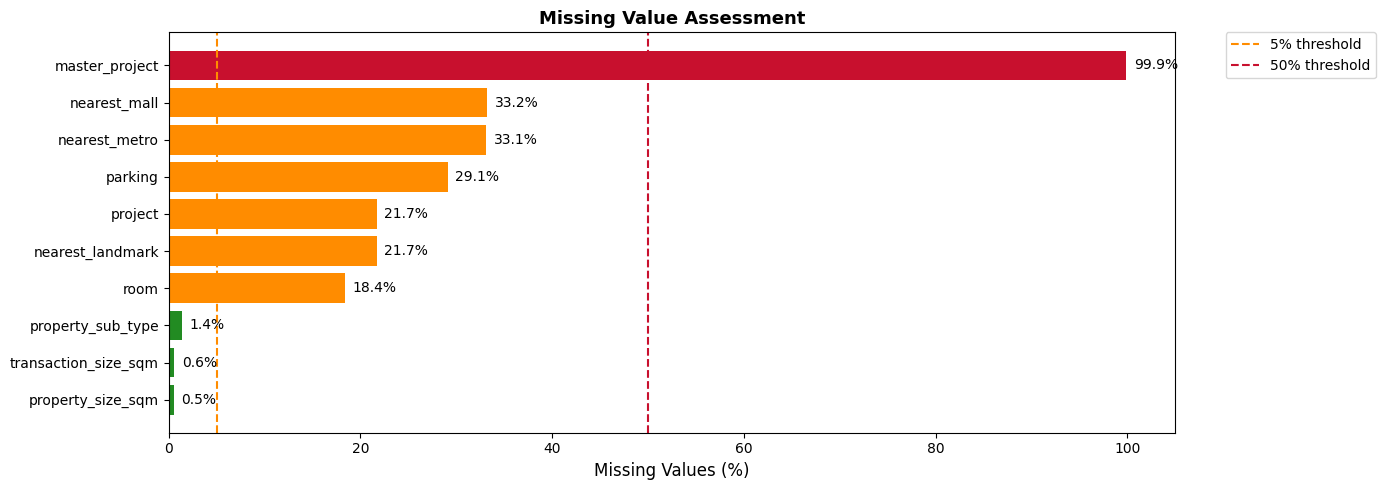

In [194]:
# Visualising the missingness of the values
fig, ax = plt.subplots(figsize=(14, 5)) # Increased width to 14

missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_to_plot = missing_pct[missing_pct > 0].sort_values(ascending=True) # Changed to ascending=True

# Colour each bar by risk level
colours = ['#C8102E' if p > 50 else ('#FF8C00' if p > 5 else '#228B22')
           for p in missing_to_plot.values]

bars = ax.barh(missing_to_plot.index, missing_to_plot.values, color=colours)

# Add percentage labels
for bar, pct in zip(bars, missing_to_plot.values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2, # Adjusted offset for better visibility
            f'{pct:.1f}%', va='center', fontsize=10)

# Reference threshold lines
ax.axvline(x=5,  color='#FF8C00', linestyle='--', lw=1.5, label='5% threshold')
ax.axvline(x=50, color='#C8102E', linestyle='--', lw=1.5, label='50% threshold')

ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Missing Value Assessment',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Moved legend outside
ax.set_xlim(0, 105) # Extended x-axis to 105 to show 100% and label
plt.tight_layout()
plt.show()

## 4. Duplicate Records and Key Integrity

In [195]:
# 4a. Count EXACT duplicate rows (identical across ALL columns)
exact_dups = df.duplicated().sum()
print('=' * 60)
print('EXACT DUPLICATE ROWS')
print('=' * 60)
print(f'  Number of exact duplicate rows: {exact_dups}')
print(f'  Duplicate percentage: {(exact_dups/df.shape[0]*100).round(2)}%')

# 4b. Key integrity check — is transaction_number unique?
print('=' * 60)
print('KEY INTEGRITY: transaction_number')
print('=' * 60)
is_unique = df['transaction_number'].is_unique
print(f'  transaction_number is unique: {is_unique}')
if not is_unique:
    dup_count = df['transaction_number'].duplicated().sum()
    print(f'  Duplicate transaction_number values: {dup_count}')


print()

# 4c. Key integrity summary
print('=' * 60)
print('KEY INTEGRITY SUMMARY')
print('=' * 60)
print(f'  Total rows                : {len(df)}')
print(f'  Unique transaction_number : {df["transaction_number"].nunique()}')
print(f'  Duplicate number rows     : {len(df) - df["transaction_number"].nunique()}')
print(f'  Violation rate            : {(len(df) - df["transaction_number"].nunique()) / len(df) * 100:.1f}%')

EXACT DUPLICATE ROWS
  Number of exact duplicate rows: 808
  Duplicate percentage: 0.99%
KEY INTEGRITY: transaction_number
  transaction_number is unique: False
  Duplicate transaction_number values: 5753

KEY INTEGRITY SUMMARY
  Total rows                : 81601
  Unique transaction_number : 75848
  Duplicate number rows     : 5753
  Violation rate            : 7.1%


**Visualising the uniqueness**

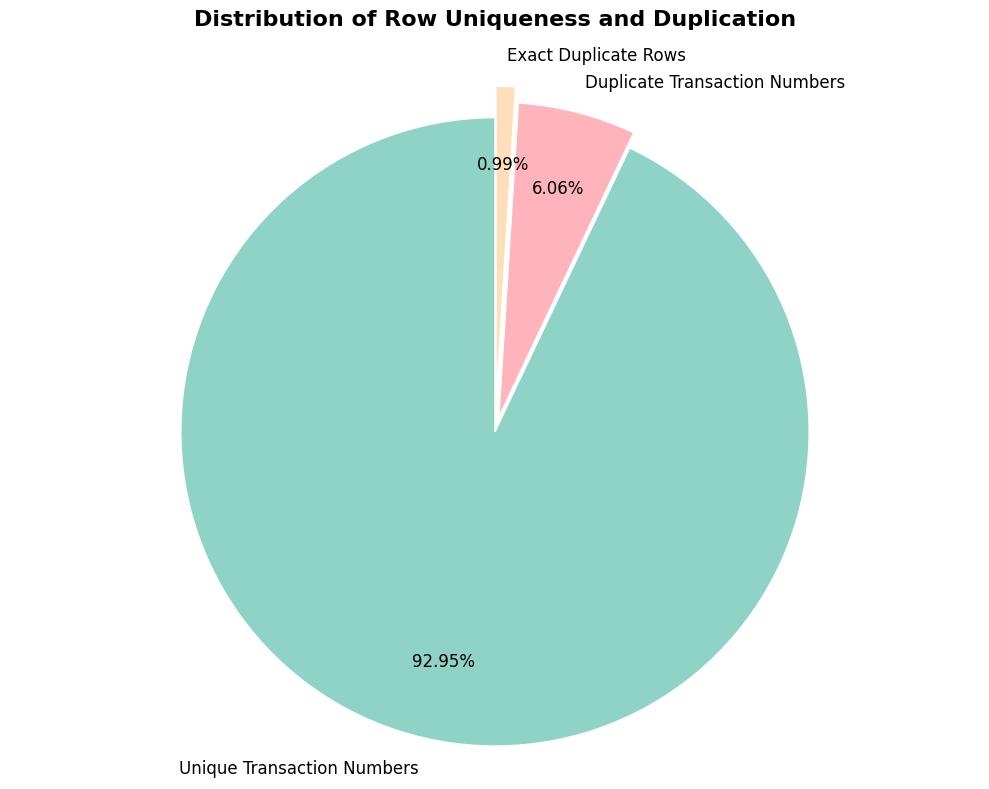

In [196]:
total_rows = len(df)
unique_transaction_numbers = df["transaction_number"].nunique()
duplicate_transaction_number_total = total_rows - unique_transaction_numbers
exact_duplicate_rows = df.duplicated().sum()

# Calculate sizes for the three distinct slices
# 1. Rows with unique transaction numbers
size_unique_tn = unique_transaction_numbers
# 2. Rows with duplicate transaction numbers but are NOT exact duplicates
size_duplicate_tn_only = duplicate_transaction_number_total - exact_duplicate_rows
# 3. Rows that are exact duplicates (which also implies duplicate transaction numbers)
size_exact_duplicates = exact_duplicate_rows

# Handle potential edge cases where duplicate_tn_only might be negative if exact_duplicates > duplicate_transaction_number_total
# (though unlikely with current data where exact_duplicates are a subset)
if size_duplicate_tn_only < 0:
    size_duplicate_tn_only = 0
    # If exact duplicates exceed total transaction number duplicates, adjust exact duplicates accordingly.
    # This scenario is highly improbable given standard data definition, but for robustness:
    size_exact_duplicates = duplicate_transaction_number_total # all duplicate TNs are exact duplicates

sizes = [size_unique_tn, size_duplicate_tn_only, size_exact_duplicates]

# Labels for the pie chart slices
labels = [
    f'Unique Transaction Numbers',
    f'Duplicate Transaction Numbers',
    f'Exact Duplicate Rows'
]

# Define colors for better distinction
colors = ['#8fd3c7', '#ffb3ba', '#ffdfba'] # Blue-green, light red, light orange
explode = [0, 0.05, 0.1] # Explode duplicate slices for emphasis

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.2f%%', startangle=90,
                                  pctdistance=0.75, textprops={'fontsize': 12, 'color': 'black'},
                                  wedgeprops={'edgecolor': 'white'})

# Add a title to the plot
ax.set_title('Distribution of Row Uniqueness and Duplication', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

## 5. Categorical Consistency Checks

In [197]:
categorical_cols = df.select_dtypes(include='object').columns

# 5a. Inspect each categorical column
print('=' * 60)
print('UNIQUE VALUES CHECK')
print('=' * 60)
for col in categorical_cols:
    print(f'{'─'*55}')
    print(f'COLUMN: {col}')
    print(f'{'─'*55}')
    vc = df[col].value_counts()
    print(f'  Unique values found  : {vc.shape[0]}')
    print(f'\nUnique values for {col}:')
    print(df[col].unique())
    print()

# 5b. Detect whitespace contamination
print('=' * 60)
print('WHITESPACE CONTAMINATION CHECK')
print('=' * 60)
for col in categorical_cols:
    has_ws = df[col].apply(
        lambda x: x != x.strip() if isinstance(x, str) else False
    ).sum()
    if has_ws > 0:
        print(f'  {col}: {has_ws} values with leading/trailing whitespace')

print()

# 5c. Flag low-frequency categories (< 5 occurrences — likely typos or errors)
print('=' * 60)
print('COLUMNS WITH LOW-FREQUENCY VALUES (threshold = 5)')
print('=' * 60)
threshold = 5
for col in categorical_cols:
    low_freq = df[col].value_counts()[df[col].value_counts() < threshold]
    if len(low_freq) > 0:
        print(f'  {col}')
    else:
        continue


UNIQUE VALUES CHECK
───────────────────────────────────────────────────────
COLUMN: transaction_number
───────────────────────────────────────────────────────
  Unique values found  : 75848

Unique values for transaction_number:
['102-1-2023' '102-10-2023' '102-100-2023' ... '95-3-2023' '95-4-2023'
 '95-5-2023']

───────────────────────────────────────────────────────
COLUMN: transaction_date
───────────────────────────────────────────────────────
  Unique values found  : 41181

Unique values for transaction_date:
['1/2/2023 7:25' '1/2/2023 8:06' '1/2/2023 9:01' ... '3/7/2023 10:07'
 '3/19/2023 17:34' '1/9/2023 9:48']

───────────────────────────────────────────────────────
COLUMN: transaction_type
───────────────────────────────────────────────────────
  Unique values found  : 3

Unique values for transaction_type:
['Sales' 'Mortgage' 'Gifts']

───────────────────────────────────────────────────────
COLUMN: transaction_sub_type
───────────────────────────────────────────────────────
 

## 6. Numeric Distributions and Outlier Detection

In [198]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('=' * 60)
print('SUMMARY STATISTICS')
print('=' * 60)
print(df[numeric_cols].describe().round(2).to_string())

print()

# Ensure 'transaction_date' is datetime type for comparison
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
current_date = pd.Timestamp.now()

# 6a. Domain-knowledge range checks
# These are the simplest checks — use knowledge of the domain to spot impossible values
print('=' * 60)
print('DOMAIN-KNOWLEDGE RANGE CHECKS')
print('=' * 60)

impossible_date = df[df['transaction_date'] > current_date]  # transaction_date must be in the past
print(f'  Impossible future dates: {len(impossible_date)} rows')
if len(impossible_date) > 0:
    print(f'  Values: {impossible_date["transaction_date"].tolist()}')

negative_purchases = df[df['amount'] < 0]  # transaction amount cannot be negative
print(f'  Negative purchase amounts: {len(negative_purchases)} rows')
if len(negative_purchases) > 0:
    print(f'  Values: {negative_purchases["amount"].round(2).tolist()}')

negative_num_of_buyer = df[df['no_of_buyer'] < 0] # number of buyers cannot be negative
print(f'  Negative number of buyers: {len(negative_num_of_buyer)} rows')
if len(negative_num_of_buyer) > 0:
    print(f'  Values: {negative_num_of_buyer["no_of_buyer"].tolist()}')

negative_num_of_seller = df[df['no_of_seller'] < 0] # number of sellers cannot be negative
print(f'  Negative number of sellers: {len(negative_num_of_seller)} rows')
if len(negative_num_of_seller) > 0:
    print(f'  Values: {negative_num_of_seller["no_of_seller"].tolist()}')

negative_property_size = df[df['property_size_sqm'] <=0] # property size must be positive
print(f'  Negative property size: {len(negative_property_size)} rows')
if len(negative_num_of_buyer) > 0:
    print(f'  Values: {negative_property_size["property_size_sqm"].tolist()}')

negative_transaction_size = df[df['transaction_size_sqm'] <0] # transaction size cannot be negative
print(f'  Negative transaction size: {len(negative_transaction_size)} rows')
if len(negative_num_of_buyer) > 0:
    print(f'  Values: {negative_property_size['transaction_size_sqm'].tolist()}')


print()

# 6b. IQR-based outlier detection
# The IQR method is robust and does not assume a normal distribution
print('=' * 60)
print('IQR-BASED OUTLIER DETECTION')
print('=' * 60)

def iqr_outliers(series, col_name):
    Q1  = series.quantile(0.25)  # 25th percentile
    Q3  = series.quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1                # Interquartile range
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = series[(series < lower_fence) | (series > upper_fence)]
    print(f'  Column: {col_name}')
    print(f'    Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}')
    print(f'    Fences: [{lower_fence:.2f}, {upper_fence:.2f}]')
    print(f'    Flagged outliers: {len(outliers)} rows ({len(outliers)/len(series)*100:.1f}%)')
    if len(outliers) > 0:
        print(f'    Values: {sorted(outliers.values)[:10]}')
    print()

for col in ['property_size_sqm', 'amount', 'no_of_buyer','no_of_seller']:
    iqr_outliers(df[col].dropna(), col)


SUMMARY STATISTICS
             amount  transaction_size_sqm  property_size_sqm  no_of_buyer  no_of_seller
count  8.160100e+04              81118.00           81193.00     81601.00      81601.00
mean   3.124265e+06                726.55             751.17         0.87          0.82
std    2.145941e+07              69252.76           69268.78         0.63          0.74
min    5.700000e+01                  0.00               6.43         0.00          0.00
25%    7.250000e+05                 67.88              68.51         0.00          0.00
50%    1.440000e+06                106.15             107.78         1.00          1.00
75%    2.596020e+06                186.58             188.23         1.00          1.00
max    3.869204e+09           18866775.24        18866775.24        12.00         29.00

DOMAIN-KNOWLEDGE RANGE CHECKS
  Impossible future dates: 0 rows
  Negative purchase amounts: 0 rows
  Negative number of buyers: 0 rows
  Negative number of sellers: 0 rows
  Negative prop

**Visualising numeric values distribution**

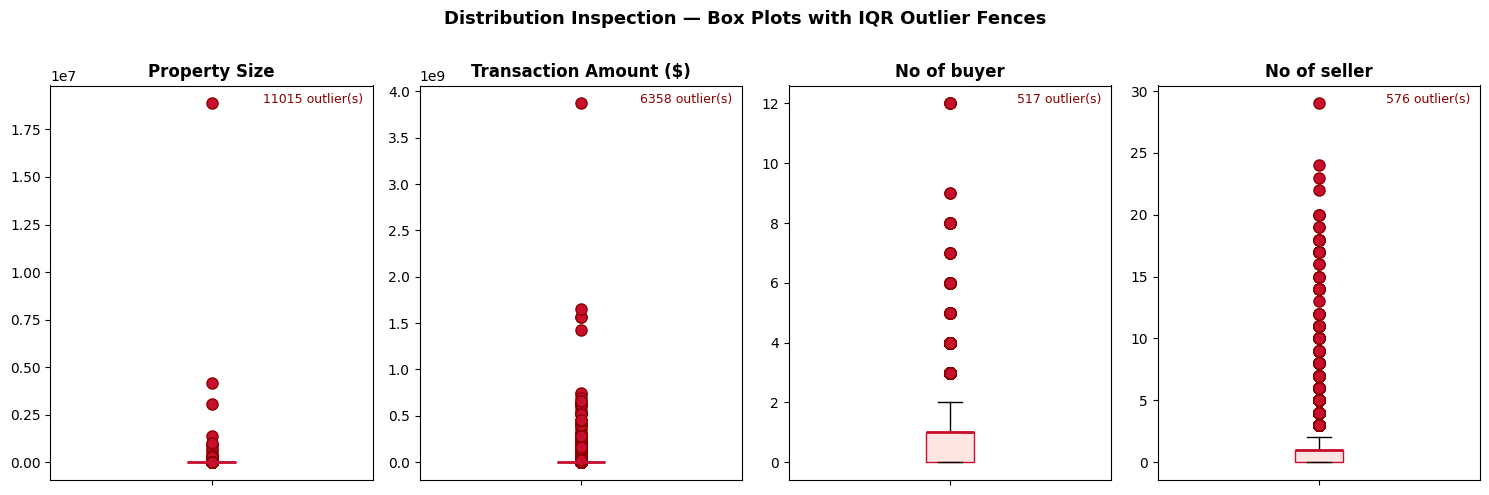

In [199]:
# 6b: Visualise distributions

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle('Distribution Inspection — Box Plots with IQR Outlier Fences',
             fontsize=13, fontweight='bold')

plot_cols = ['property_size_sqm', 'amount', 'no_of_buyer','no_of_seller']
titles = ['Property Size', 'Transaction Amount ($)', 'No of buyer','No of seller']

for ax, col, title in zip(axes, plot_cols, titles):
    data = df[col].dropna()
    # Box plot spans Q1-Q3; whiskers extend to IQR fences
    # Individual points beyond whiskers = flagged outliers
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#FFE4E4', color='#C8102E'),
               medianprops=dict(color='#C8102E', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#C8102E',
                               markeredgecolor='darkred', markersize=8))
    ax.set_title(title, fontweight='bold')
    ax.tick_params(labelbottom=False)
    # Annotate outlier count
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)).sum()
    ax.text(0.97, 0.98, f'{n_out} outlier(s)', transform=ax.transAxes,
            fontsize=9, color='darkred', va='top', ha='right')

plt.tight_layout()
plt.show()


In [200]:
# Extreme values
print('=' * 60)
print('EXTREME VALUES')
sig_size = (df['property_size_sqm']>0.25e7).sum()
sig_amount = (df['amount']>1e9).sum()
print('=' * 60)
print(f'{'─'*55}')
print('COLUMN: property_size_sqm')
print(f'There are 11,015 outliers, including {sig_size} extremely high value')
print(f'{'─'*55}')
print('COLUMN: amount')
print(f'There are 6358 outliers, including {sig_amount} extremely high value')
print(f'{'─'*55}')


EXTREME VALUES
───────────────────────────────────────────────────────
COLUMN: property_size_sqm
There are 11,015 outliers, including 3 extremely high value
───────────────────────────────────────────────────────
COLUMN: amount
There are 6358 outliers, including 5 extremely high value
───────────────────────────────────────────────────────


## 7. The Data Assessment Summary

In [201]:
# ── Data Assessment Summary ──────────────────────────────────

print('=' * 70)
print('  DATA ASSESSMENT SUMMARY')
print('=' * 70)

# ── Component 1: Dataset Overview ────────────────────────────────────
print('COMPONENT 1: DATASET OVERVIEW')
print('-' * 50)
print(f'  Source       : Dubai Property Sales Data')
print(f'  Rows         : {df.shape[0]:,}')
print(f'  Columns      : {df.shape[1]}')
print(f'  Unit of analysis: One row = one property transaction (sale transaction) in Dubai')
print(f'  Time period  : First 6 months 2023')
print()

# ── Component 2: Structure and Type Findings ─────────────────────────
print('COMPONENT 2: TYPE FINDINGS')
print('-' * 50)
type_issues = [
    ('transaction_date', 'object',  'datetime64',   'HIGH', 'String format prevents time-series operations')
]
print(f'  {"Column":<20} {"Current":<12} {"Needed":<13} {"Risk":<8} Note')
print(f'  {"-"*20} {"-"*12} {"-"*13} {"-"*8} {"-"*30}')
for col, current, needed, risk, note in type_issues:
    print(f'  {col:<20} {current:<12} {needed:<13} {risk:<8} {note}')
print()

# ── Component 3: Quality Findings ────────────────────────────────────
print('COMPONENT 3: QUALITY FINDINGS')
print('-' * 50)

# 1. Missingness
print('  [Missingness]')
missing_pct_quality = (df.isnull().sum() / len(df) * 100)
for col, pct in missing_pct_quality.items():
    if pct > 0:
        risk = 'HIGH' if pct > 50 else ('MODERATE' if pct > 5 else 'LOW')
        print(f'    * {col:<20}: {pct:.1f}% missing -- {risk} risk')
print()

# 2. Duplicates
key_dups_summary  = df['transaction_number'].duplicated().sum()
print(f'  [Duplicates]')
print(f'    * Exact duplicate rows                     : 808)')
print(f'    * transaction_number key integrity failures: {key_dups_summary} duplicate transaction_number')
print()

# 3. Categorical
print(f'  [Categorical Consistency]')
print(f'    * room             : inconsistent data (1 B/R, 1 bedroom)')
print(f'    * parking          : should contain 2 value (''has parking'', ''no parking'') instead of slot codes')
print(f'    * Other columns    : whitespace detected in area, transaction_sub_type, nearest_metro, master_project; text format is needed for area, room, project')
print()

# 4. Outliers
print(f'  [Outliers and Range Violations]')
print(f'    0 impossible values')
print(f'    * amount           : fences [-2081530.00, 5402550.00], 6358 rows (7.8%) outliers, with 1 extreme value')
print(f'    * property_size_sqm: fences [-111.07, 367.81], 11015 rows (13.6%) outliers, with 5 extreme values')
print(f'    * no_of_buyer      : fences [-1.50, 2.50], 517 rows (0.6%) outliers')
print(f'    * no_of_seller     : fences [-1.50, 2.50], 576 rows (0.7%) outliers')

print()

# ── Component 4: Risk Rating ──────────────────────────────────────────
print('COMPONENT 4: OVERALL RISK RATING')
print('-' * 50)
print('  Risk Level: MEDIUM-HIGH')
print('  Justification:')
print('  (a) `transaction_date` is not in datetime format, hindering time-series analysis.')
print('  (b) Significant missing data in `master_project` (99.9%), and moderate missingness in several other key columns (`parking`, `nearest_metro`, `nearest_mall`, `nearest_landmark`, `project`, `room`).')
print('  (c) Duplicate rows and potential key integrity issues for `transaction_number` may inflate counts.')
print('  (d) Categorical inconsistencies (e.g., whitespace) in `area`, `project`, and other string columns affect aggregation and analysis.')
print('  (e) Numerous outliers detected in critical numerical fields (`amount`, `property_size_sqm`, `no_of_buyer`, `no_of_seller`), requiring investigation.')
print('  The dataset requires substantial cleaning before reliable analysis or modeling.')
print()

# ── Component 5: Next Steps ───────────────────────────────────────────
print('COMPONENT 5: RECOMMENDED NEXT STEPS (Data Cleaning)')
print('-' * 50)
actions = [
    ('1', 'Data Types', 'Convert ''transaction_date'' to datetime objects for proper time-series analysis.'),
    ('2', 'Duplicate records',  'Remove exact duplicate rows and investigate duplicate `transaction_number` keys.'),
    ('3', 'Categorical columns', 'Clean whitespace (str.strip()), format text.'),
    ('4', 'Missing values',     'Strategically handle missing values in `master_project`, and impute or drop for other columns (`parking`, `nearest_metro`, `nearest_mall`, `nearest_landmark`, `project`, `room`) based on impact.'),
    ('5', 'Numerical outliers', 'Investigate and address outliers in `amount`, `property_size_sqm`, `no_of_buyer`, `no_of_seller` using appropriate methods.')
]
for num, col, action in actions:
    print(f'  {num}. [{col}] {action}')

print()
print('=' * 70)
print('  END OF DATA ASSESSMENT SUMMARY')
print('=' * 70)

  DATA ASSESSMENT SUMMARY
COMPONENT 1: DATASET OVERVIEW
--------------------------------------------------
  Source       : Dubai Property Sales Data
  Rows         : 81,601
  Columns      : 22
  Unit of analysis: One row = one property transaction (sale transaction) in Dubai
  Time period  : Jan-Apr 2023 (transaction_date range)

COMPONENT 2: TYPE FINDINGS
--------------------------------------------------
  Column               Current      Needed        Risk     Note
  -------------------- ------------ ------------- -------- ------------------------------
  transaction_date     object       datetime64    HIGH     String format prevents time-series operations

COMPONENT 3: QUALITY FINDINGS
--------------------------------------------------
  [Missingness]
    * property_sub_type   : 1.4% missing -- LOW risk
    * transaction_size_sqm: 0.6% missing -- LOW risk
    * property_size_sqm   : 0.5% missing -- LOW risk
    * room                : 18.4% missing -- MODERATE risk
    * parking 

**Data Assessment Dashboard**

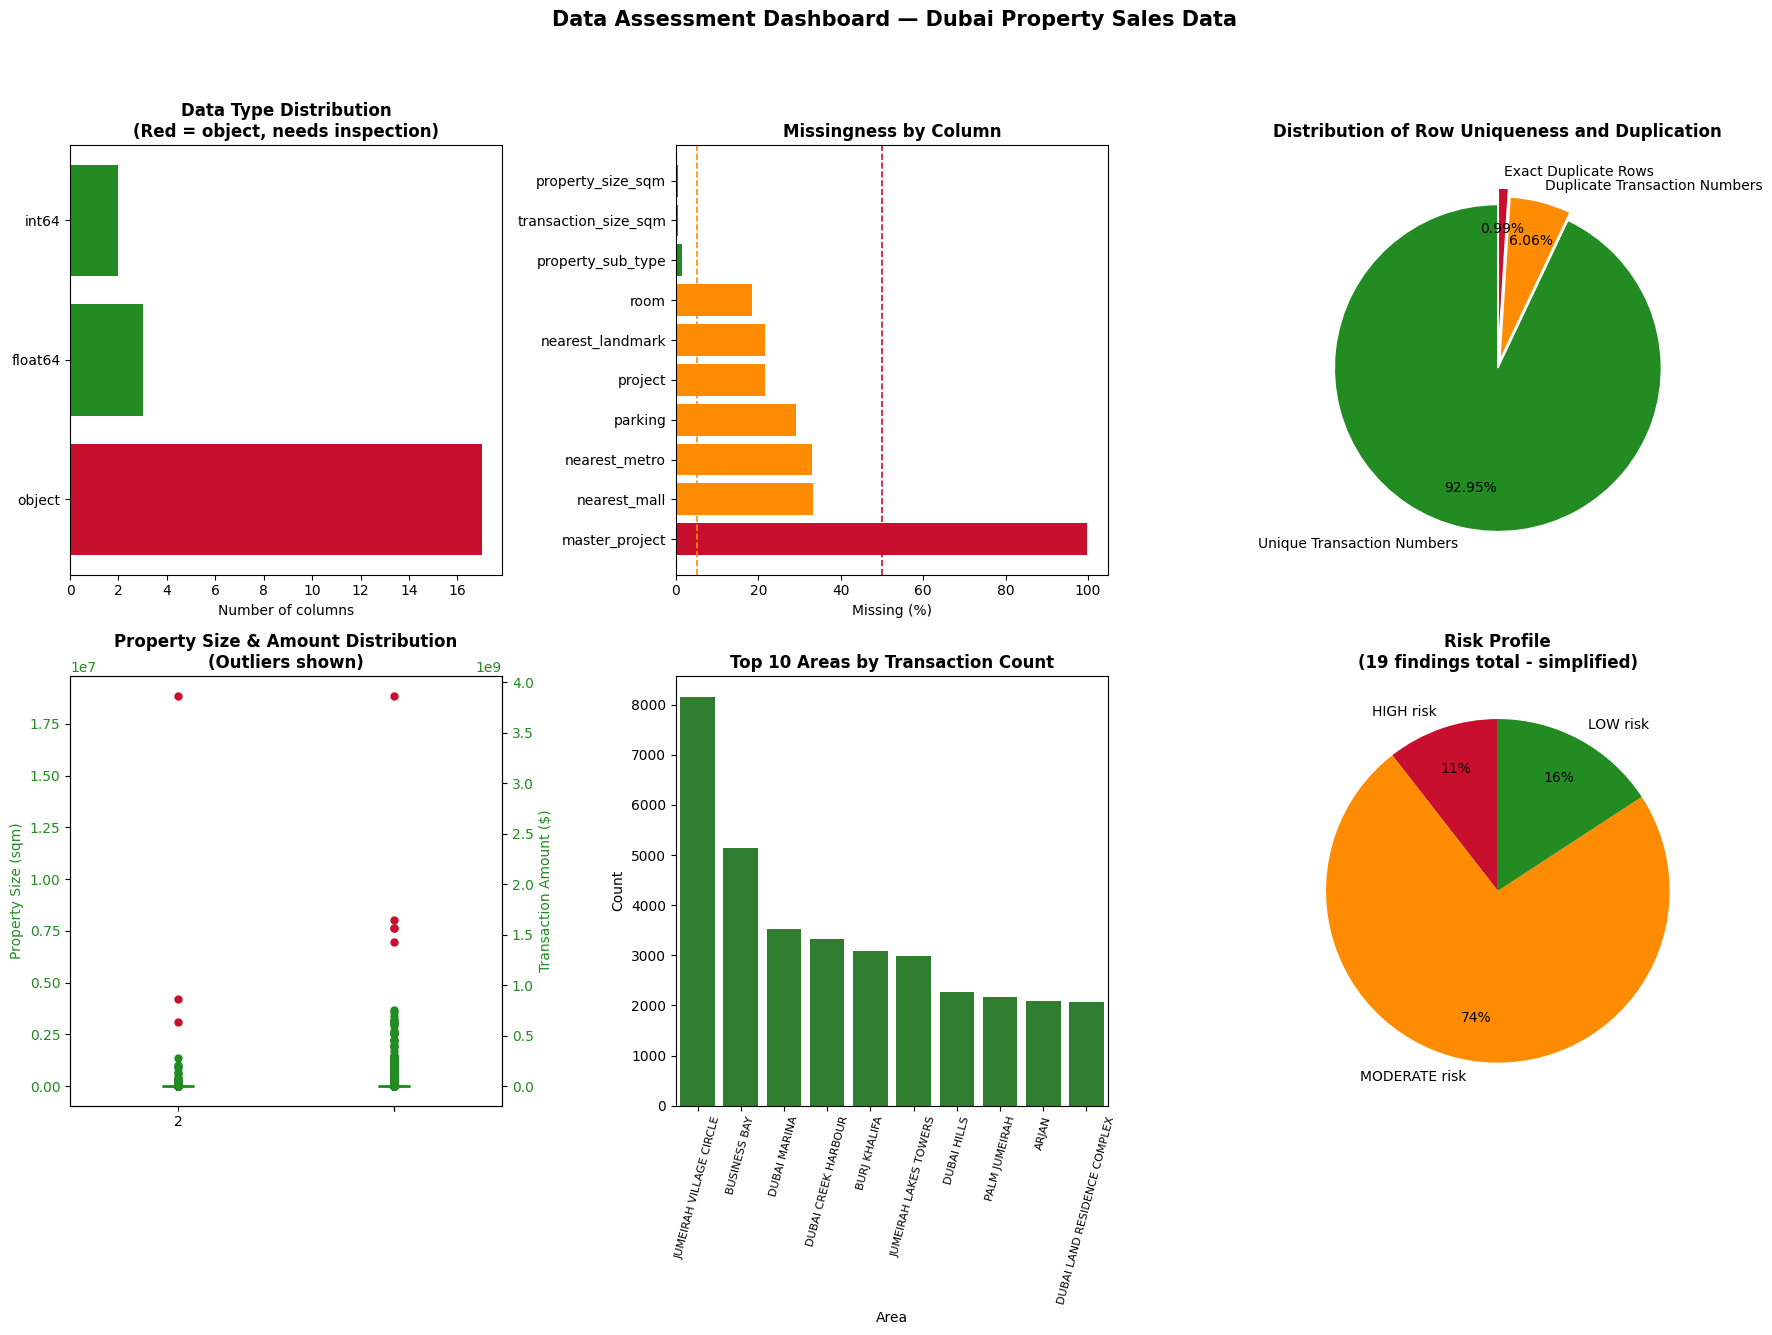

In [202]:
fig = plt.figure(figsize=(18, 14)) # Increased figure size for better readability
fig.suptitle('Data Assessment Dashboard — Dubai Property Sales Data', fontsize=15, fontweight='bold', y=0.98)
df = pd.read_csv("dubai_property_sales.csv")
missing_pct = (df.isnull().sum() / len(df) * 100)

# ─── Panel 1: Data Type Count ───────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
dtype_counts = df.dtypes.value_counts()
dtype_labels = [str(d) for d in dtype_counts.index]
colours_d = []
for d in dtype_counts.index:
    if 'object' in str(d):
        colours_d.append('#C8102E') # Red for object
    elif 'int' in str(d) or 'float' in str(d):
        colours_d.append('#228B22') # Green for int and float
    else:
        colours_d.append('#1A5276') # Default blue for others
ax1.barh(dtype_labels, dtype_counts.values, color=colours_d)
ax1.set_title('Data Type Distribution\n(Red = object, needs inspection)', fontweight='bold')
ax1.set_xlabel('Number of columns')

# ─── Panel 2: Missingness by Column ───────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
missing_to_plot = missing_pct[missing_pct > 0].sort_values(ascending=False)
colours = ['#C8102E' if p > 50 else ('#FF8C00' if p > 5 else '#228B22')
           for p in missing_to_plot.values]
ax2.barh(missing_to_plot.index, missing_to_plot.values, color=colours)
ax2.axvline(5, color='#FF8C00', ls='--', lw=1.2)
ax2.axvline(50, color='#C8102E', ls='--', lw=1.2)
ax2.set_title('Missingness by Column', fontweight='bold')
ax2.set_xlabel('Missing (%)')

# ─── Panel 3: Uniqueness Pie Chart ────────────────
ax3 = fig.add_subplot(2, 3, 3)
# Re-calculate values for the pie chart
total_rows = len(df)
unique_transaction_numbers = df["transaction_number"].nunique()
exact_duplicate_rows = df.duplicated().sum()
duplicate_transaction_number_total = total_rows - unique_transaction_numbers

# Rows with unique transaction numbers
size_unique_tn = unique_transaction_numbers
# Rows with duplicate transaction numbers but are NOT exact duplicates
size_duplicate_tn_only = duplicate_transaction_number_total - exact_duplicate_rows
# Rows that are exact duplicates
size_exact_duplicates = exact_duplicate_rows

sizes_pie = [size_unique_tn, size_duplicate_tn_only, size_exact_duplicates]
labels_pie = [
    f'Unique Transaction Numbers',
    f'Duplicate Transaction Numbers',
    f'Exact Duplicate Rows'
]
colors_pie = ['#228B22', '#FF8C00', '#C8102E'] # Green, Orange, Red
explode_pie = [0, 0.05, 0.1] # Explode duplicate slices for emphasis

wedges, texts, autotexts = ax3.pie(sizes_pie, explode=explode_pie, labels=labels_pie, colors=colors_pie,
                                  autopct='%1.2f%%', startangle=90,
                                  pctdistance=0.75, textprops={'fontsize': 10, 'color': 'black'},
                                  wedgeprops={'edgecolor': 'white'})
ax3.set_title('Distribution of Row Uniqueness and Duplication', fontsize=12, fontweight='bold')
ax3.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# ─── Panel 4: Property Size and Amount box plots ─
ax4_main = fig.add_subplot(2, 3, 4) # Main axis for property size

# --- Property Size Boxplot ---
size_data = df['property_size_sqm'].dropna()
Q1_size, Q3_size = size_data.quantile(0.25), size_data.quantile(0.75)
IQR_size = Q3_size - Q1_size
lower_fence_size = Q1_size - 1.5 * IQR_size
upper_fence_size = Q3_size + 1.5 * IQR_size

extreme_outliers_size = size_data[size_data > 0.25e7]
regular_outliers_size = size_data[((size_data < lower_fence_size) | (size_data > upper_fence_size)) & (size_data <= 0.25e7)]
non_outlier_size_data = size_data[(size_data >= lower_fence_size) & (size_data <= upper_fence_size)]

# Plot the box and whiskers (excluding fliers by default)
bp_size = ax4_main.boxplot(non_outlier_size_data, positions=[1], patch_artist=True,
                           boxprops=dict(facecolor='#E6FAE6', color='#228B22'),
                           medianprops=dict(color='#228B22', linewidth=2),
                           whiskerprops=dict(color='#228B22'),
                           capprops=dict(color='#228B22'),
                           showfliers=False) # Don't show default fliers

# Manually plot regular outliers in green
ax4_main.plot(np.full_like(regular_outliers_size, 1), regular_outliers_size,
              'o', markerfacecolor='#228B22', markeredgecolor='#228B22', markersize=5)

# Manually plot extreme outliers in red
ax4_main.plot(np.full_like(extreme_outliers_size, 1), extreme_outliers_size,
              'o', markerfacecolor='#C8102E', markeredgecolor='#C8102E', markersize=5)


ax4_main.set_ylabel('Property Size (sqm)', color='#228B22')
ax4_main.tick_params(axis='y', labelcolor='#228B22')
ax4_main.set_xticks([1, 2]) # Set dummy x-ticks for both boxplots
ax4_main.set_xticklabels(['Property Size', 'Amount'])


ax4_twin = ax4_main.twinx() # Create a twin axis for amount

# --- Amount Boxplot ---
amount_data = df['amount'].dropna()
Q1_amount, Q3_amount = amount_data.quantile(0.25), amount_data.quantile(0.75)
IQR_amount = Q3_amount - Q1_amount
lower_fence_amount = Q1_amount - 1.5 * IQR_amount
upper_fence_amount = Q3_amount + 1.5 * IQR_amount

extreme_outliers_amount = amount_data[amount_data > 1e9]
regular_outliers_amount = amount_data[((amount_data < lower_fence_amount) | (amount_data > upper_fence_amount)) & (amount_data <= 1e9)]
non_outlier_amount_data = amount_data[(amount_data >= lower_fence_amount) & (amount_data <= upper_fence_amount)]

# Plot the box and whiskers (excluding fliers by default)
bp_amount = ax4_twin.boxplot(non_outlier_amount_data, positions=[2], patch_artist=True,
                             boxprops=dict(facecolor='#E6FAE6', color='#228B22'),
                             medianprops=dict(color='#228B22', linewidth=2),
                             whiskerprops=dict(color='#228B22'),
                             capprops=dict(color='#228B22'),
                             showfliers=False) # Don't show default fliers

# Manually plot regular outliers in green
ax4_twin.plot(np.full_like(regular_outliers_amount, 2), regular_outliers_amount,
              'o', markerfacecolor='#228B22', markeredgecolor='#228B22', markersize=5)

# Manually plot extreme outliers in red
ax4_twin.plot(np.full_like(extreme_outliers_amount, 2), extreme_outliers_amount,
              'o', markerfacecolor='#C8102E', markeredgecolor='#C8102E', markersize=5)

ax4_twin.set_ylabel('Transaction Amount ($)', color='#228B22')
ax4_twin.tick_params(axis='y', labelcolor='#228B22')

ax4_main.set_title('Property Size & Amount Distribution\n(Outliers shown)', fontweight='bold', fontsize=12)

# ─── Panel 5: Transaction Count Distribution ────────────────
ax5 = fig.add_subplot(2, 3, 5)
area_vc = df['area'].value_counts()
# Use a single green color
sns.barplot(x=area_vc.index[:10], y=area_vc.values[:10], ax=ax5, color='#228B22') # Green color
ax5.set_title('Top 10 Areas by Transaction Count', fontweight='bold')
ax5.set_xlabel('Area', fontsize=10) # Set font size for x-axis label
ax5.tick_params(axis='x', labelsize=8, rotation=75)
ax5.set_ylabel('Count')

# ─── Panel 6: Risk summary ─────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
# Based on the DATA ASSESSMENT SUMMARY from cell 6Nv1I5mgNbUt
# HIGH: transaction_date (type), master_project (missing)
# MODERATE: room, parking, nearest_metro, nearest_mall, nearest_landmark, project (missing); transaction_number (duplicates); area, project, other categorical (consistency); amount, property_size_sqm, no_of_buyer, no_of_seller (outliers)
# LOW: property_sub_type, transaction_size_sqm, property_size_sqm (missing)

# Aggregated counts: 2 HIGH, ~14 MODERATE, ~3 LOW
pie_values = [2, 14, 3] # Simplified representation
pie_labels = ['HIGH risk', 'MODERATE risk', 'LOW risk']
pie_colors = ['#C8102E', '#FF8C00', '#228B22']

ax6.pie(pie_values, labels=pie_labels, colors=pie_colors, autopct='%1.0f%%',
        pctdistance=0.75, startangle=90)
ax6.set_title(f'Risk Profile\n({sum(pie_values)} findings total - simplified)', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

#Transform

## 1. Converting data types

In [203]:
print('Variable types before changing:')
print(df.dtypes)

# Converting'transaction_date' to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print('\nVariable types after changing:')
print(df.dtypes)

Variable types before changing:
transaction_number       object
transaction_date         object
transaction_type         object
transaction_sub_type     object
registration_type        object
is_free_hold             object
usage                    object
area                     object
property_type            object
property_sub_type        object
amount                  float64
transaction_size_sqm    float64
property_size_sqm       float64
room                     object
parking                  object
nearest_metro            object
nearest_mall             object
nearest_landmark         object
no_of_buyer               int64
no_of_seller              int64
master_project           object
project                  object
dtype: object

Variable types after changing:
transaction_number              object
transaction_date        datetime64[ns]
transaction_type                object
transaction_sub_type            object
registration_type               object
is_free_hold           

## 2. Removing duplicate records

In [204]:
# 1a. Confirm duplicates before removing
print('=' * 60)
print('BEFORE deduplication:')
print('=' * 60)
print(f'  Total rows                : {len(df)}')
print(f'  Exact duplicate rows      : {df.duplicated().sum()}')
print(f'  Unique transaction_number : {df["transaction_number"].nunique()}')
print()

BEFORE deduplication:
  Total rows                : 81601
  Exact duplicate rows      : 808
  Unique transaction_number : 75848



In [205]:
# 1b. Drop exact duplicate rows
print('=' * 60)
print("CLEANING: Exact duplicate rows")
print('=' * 60)
rows_before = len(df)
df = df.drop_duplicates(keep='first')
rows_after  = len(df)

print(f'Rows before deduplication : {rows_before}')
print(f'Rows after deduplication  : {rows_after}')
print(f'Rows removed              : {rows_before - rows_after}')
print()
print('Exact duplicates removed.')

# 1c. Verify key integrity
print('=' * 60)
print('AFTER deduplication:')
print('=' * 60)
print(f'  Total rows                  : {len(df)}')
print(f'  Unique transaction_number   : {df["transaction_number"].nunique()}')
print(f'  transaction_number is unique: {df["transaction_number"].is_unique}')
print()

if df['transaction_number'].is_unique:
    print('✅ Key integrity confirmed — every transaction_number is now unique.')
else:
    print('⚠️ Duplicate customer_ids still exist — further investigation required.')
    display(df[df.duplicated(subset=['transaction_number'], keep=False)].sort_values('transaction_number'))

CLEANING: Exact duplicate rows
Rows before deduplication : 81601
Rows after deduplication  : 80793
Rows removed              : 808

Exact duplicates removed.
AFTER deduplication:
  Total rows                  : 80793
  Unique transaction_number   : 75848
  transaction_number is unique: False

⚠️ Duplicate customer_ids still exist — further investigation required.


,transaction_number,transaction_date,transaction_type,transaction_sub_type,registration_type,is_free_hold,usage,area,property_type,property_sub_type,...,property_size_sqm,room,parking,nearest_metro,nearest_mall,nearest_landmark,no_of_buyer,no_of_seller,master_project,project
31880,11-11286-2023,2023-04-17 09:33:00,Sales,Sale,Ready,Free Hold,Residential,DUBAI SPORTS CITY,Unit,Flat,...,42.79,Studio,P-022,Dubai Internet City,Marina Mall,Sports City Swimming Academy,1,1,NaN,ELITE II SPORTS RESIDENCE
31881,11-11286-2023,2023-04-17 09:33:00,Sales,Sale,Ready,Free Hold,Residential,DUBAI SPORTS CITY,Unit,Flat,...,42.79,Studio,P-022,Nakheel Metro Station,Marina Mall,Sports City Swimming Academy,1,1,NaN,ELITE II SPORTS RESIDENCE
32033,11-11424-2023,2023-04-17 12:53:00,Sales,Sale,Ready,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Building,Villa,...,134.77,4 B/R,NaN,Dubai Internet City,Marina Mall,Sports City Swimming Academy,3,1,NaN,SEASONS COMMUNITY- SUMMER
32034,11-11424-2023,2023-04-17 12:53:00,Sales,Sale,Ready,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Building,Villa,...,134.77,4 B/R,NaN,Nakheel Metro Station,Marina Mall,Sports City Swimming Academy,3,1,NaN,SEASONS COMMUNITY- SUMMER
32241,11-11612-2023,2023-04-18 13:02:00,Sales,Sale,Ready,Free Hold,Residential,DUBAI SPORTS CITY,Unit,Flat,...,42.36,Studio,G-021,Nakheel Metro Station,Marina Mall,Sports City Swimming Academy,2,1,NaN,ELITE II SPORTS RESIDENCE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77777,715-5-2023,2023-05-19 11:55:00,Sales,Delayed Sell Lease to Own Registration,Ready,Free Hold,Residential,EMAAR SOUTH,Building,Villa,...,260.94,4 B/R,NaN,NaN,NaN,Al Makhtoum International Airport,1,1,NaN,Parkside
77778,715-6-2023,2023-06-16 11:31:00,Mortgage,Delayed Sell Lease to Own Registration,Ready,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Building,Villa,...,199.65,4 B/R,NaN,Dubai Internet City,Mall of the Emirates,Sports City Swimming Academy,1,1,NaN,ROYAL PARK SOUTH 1
77779,715-6-2023,2023-06-16 11:31:00,Sales,Delayed Sell Lease to Own Registration,Ready,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Building,Villa,...,199.65,4 B/R,NaN,Dubai Internet City,Mall of the Emirates,Sports City Swimming Academy,1,1,NaN,ROYAL PARK SOUTH 1
77780,715-7-2023,2023-06-23 10:38:00,Sales,Delayed Sell Lease to Own Registration,Ready,Free Hold,Residential,TILAL AL GHAF,Building,Villa,...,201.93,4 B/R,NaN,NaN,NaN,NaN,1,1,NaN,Elan


## 3. Fix Categorical Inconsistency and Text Format
| Column | Problem | Example | Fix strategy |
|--------|---------|---------|--------------|
| `room` | Inconsistent data | '1 bedroom' and '1 B/R' | Change 'B/R' to 'bedroom'|
| `parking`| Inconsistent data | '1 NA','N/A', '1   2', '-1'| Remove NA, remove space in the middle, absolute negative values|
| `room` | Inconsistent format | 'PENTHOUSE' and 'Studio' | Format the text|
| `area` | Inconsistent format/Whitespace | 'JUMEIRAH VILLAGE CIRCLE' / ' Dubai' | Format the text / Strip whitespace|
| `project`| Inconsistent format/Whitespace contamination | 'AYKON CITY 3' / ' Project ' | Format the text / Strip whitespace|
| `transaction_sub_type` | Whitespace contamination | 'Modify Delayed Mortgage ' | Strip whitespace|
| `parking` | Whitespace contamination | '  B2-72' | Strip whitespace|
| `nearest_metro` | Whitespace contamination | 'Terminal 3 ' | Strip whitespace|
| `master_project` | Whitespace contamination | ' Project Name ' | Strip whitespace|

In [206]:
# 2a. Correcting inconsistent values and formating text in room column
print('=' * 60)
print("CLEANING: 'room' column (replacing B/R with bedroom and format text)")
print('=' * 60)
df['room'] = df['room'].replace({
    '1 B/R': '1 bedroom',
    '2 B/R': '2 bedroom',
    '3 B/R': '3 bedroom',
    '4 B/R': '4 bedroom',
    '5 B/R': '5 bedroom',
    '6 B/R': '6 bedroom',
    '7 B/R': '7 bedroom',
    '9 B/R': '9 bedroom',
})

df['room'] = df['room'].str.lower().str.title()
print("After cleaning:", df['room'].unique())
print()

# 2b. Correcting inconsistent values and removing leading hyphens in parking column
print('=' * 60)
print("CLEANING: 'parking' column (replace values)")
print('=' * 60)

df['parking'] = df['parking'].replace({'NA': np.nan, 'N/A': np.nan})
df['parking'] = df['parking'].apply(lambda x: np.nan if str(x).startswith('-') else x)
df['parking'] = np.where(df['parking'].isna() | (df['parking'].astype(str).str.strip() == '0'),
                         'No Parking',
                         'Has Parking')

      # Display the DataFrame with the new column
print("After cleaning:", df['parking'].unique())
print()

# 2c. Formating and stripping whitespace in other categorical columns
print('=' * 60)
print("CLEANING: 'area','project', 'transaction_sub_type' and'nearest_metro' columns (stripping whitespace and format text)")
print('=' * 60)
for col in ['area','project','transaction_sub_type','nearest_metro']:
    df[col] = df[col].str.strip().str.lower().str.title()
    print(f"After cleaning '{col}':", df[col].unique())
    print()

# 2d. Formating numeric columns
print('=' * 60)
print("CLEANING: Numeric columns ( rounding transaction_size_sqm, property_size_sqm, amount to 2 decimal)")
print('=' * 60)
for col in ['transaction_size_sqm','property_size_sqm', 'amount']:
    df[col] = df[col].round(2)
    print(f"After cleaning '{col}':", df[col].unique())
    print()

CLEANING: 'room' column (replacing B/R with bedroom and format text)
After cleaning: ['2 Bedroom' 'Studio' '1 Bedroom' '3 Bedroom' '4 Bedroom' '5 Bedroom' nan
 'Shop' '6 Bedroom' 'Office' 'Penthouse' '7 Bedroom' '9 Bedroom'
 'Single Room' 'Gym' 'Hotel']

CLEANING: 'parking' column (replace values)
After cleaning: ['Has Parking' 'No Parking']

CLEANING: 'area','project', 'transaction_sub_type' and'nearest_metro' columns (stripping whitespace and format text)
After cleaning 'area': ['Business Bay' 'Al Wasl' 'Jumeirah Lakes Towers'
 'Jumeirah Village Circle' 'Dubai Creek Harbour'
 'Madinat Dubai Almelaheyah' 'Dubai Water Canal' 'Dubai Marina'
 'Town Square' 'Al Yufrah 1' 'Zaabeel First' 'Sobha Heartland'
 'Meydan One' 'Damac Hills' 'Jumeirah Village Triangle' 'Burj Khalifa'
 'Dubai Land Residence Complex' 'Wadi Al Safa 5' 'Wadi Al Safa 3'
 'The Field' "Me'Aisem First" 'Nad Al Shiba First' 'Palm Jumeirah'
 'Dubai Hills' 'Silicon Oasis' 'Jumeirah Living' 'Tecom Site A'
 'Down Town Jabal Ali

## 4. Handling missing values
Missingness before Data transform
| Column | Missingness | Problem | Fix strategy |
|--------|-------------|---------|--------------|
| master_project | 99.9% | Too many missing values | Drop the column
| nearest_metro | 33.2% | There may be no metro near this property | Fill with 'NA'
| nearest_mall | 33.2% | There may be no mall near this property | Fill with 'NA'
| parking | 28.6% | Project name might not be recorded | Fill with 'NA' |
| nearest_landmark | 21.6% | There may be no landmark near this property | Fill with 'NA'
| project | 21.4% | Project name might not be recorded | Fill with 'NA'
| room | 17.8% | Project name might not be recorded | Fill with 'NA' |
| property_sub_type | 1.4% | The corresponding value from property_type is 'Land' | Fill the missing values with 'Land'
| property_size_sqm | 0.5% |Most of the values are the same with 'transaction_size_sqm' | Fill the missing values from 'transaction_size_sqm', fill the rest with 'NA'
| transaction_size_sqm | 0.3% | Most of the values are the same with 'property_size_sqm' | Drop the column

In [207]:
# Missingness check
print('Missingness before fixing')
missing_pct_quality = (df.isnull().sum() / len(df) * 100)
for col, pct in missing_pct_quality.items():
    if pct > 0:
        risk = 'HIGH' if pct > 50 else ('MODERATE' if pct > 5 else 'LOW')
        print(f'    * {col:<20}: {pct:.1f}% missing -- {risk} risk')
print()

Missingness before fixing
    * property_sub_type   : 1.4% missing -- LOW risk
    * transaction_size_sqm: 0.3% missing -- LOW risk
    * property_size_sqm   : 0.5% missing -- LOW risk
    * room                : 17.8% missing -- MODERATE risk
    * nearest_metro       : 33.2% missing -- MODERATE risk
    * nearest_mall        : 33.2% missing -- MODERATE risk
    * nearest_landmark    : 21.6% missing -- MODERATE risk
    * master_project      : 99.9% missing -- HIGH risk
    * project             : 21.4% missing -- MODERATE risk



In [208]:
# 2a. Drop 'master_project' column
print('=' * 60)
print("DROPPING: 'master_project' column")
print('=' * 60)
if 'master_project' in df.columns:
    df.drop(columns=['master_project'], inplace=True)
    print("Dropped 'master_project' column.")
else:
    print("'master_project' column is already dropped.")


# Convert string 'nan' and 'None' to actual NaN for object columns before filling with 'NA'
# This handles cases where 'nan' or 'None' were read as string literals instead of np.nan
cols_to_check_nan_string = ['nearest_metro', 'nearest_mall', 'nearest_landmark', 'project', 'room', 'property_sub_type']
for col in cols_to_check_nan_string:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].replace({'nan': np.nan, 'NaN': np.nan, 'None': np.nan})

# 2b. Fill blank values in 'nearest_metro', 'nearest_mall', 'nearest_landmark', 'project', and'room' with NA
df['nearest_metro'] = df['nearest_metro'].fillna('NA')
df['nearest_mall'] = df['nearest_mall'].fillna('NA')
df['nearest_landmark'] = df['nearest_landmark'].fillna('NA')
df['project'] = df['project'].fillna('NA')
df['room'] = df['room'].fillna('NA')

print('Blank values in nearest_metro, nearest_mall, nearest_landmark, project, room and parking are filled with NA')

# 2c. Fill blank values in 'property_sub_type' with 'Land'
df['property_sub_type'] = df['property_sub_type'].fillna('Land')

print('Blank values in property_sub_type are filled with Land')
print()

# 2d. Treating blank values in 'transaction_size_sqm' and 'property_size_sqm values'
print('=' * 60)
print('Investigating ''transaction_size_sqm'' and ''property_size_sqm values''')
print('=' * 60)
    # The percentage of similar values between this two variables before matching
similar_size_count = (df['transaction_size_sqm'] == df['property_size_sqm']).sum()
total_rows = len(df)
percentage_similar = (similar_size_count / total_rows) * 100
print(f"Percentage of similar values between 'transaction_size_sqm' and 'property_size_sqm': {percentage_similar:.2f}%")

    # Fill missing values in 'property_size_sqm' from 'transaction_size_sqm'
df['property_size_sqm'] = df['property_size_sqm'].fillna(df['transaction_size_sqm'])
print('Missing values in property_size_sqm are filled from transaction_size_sqm')

    # Since the 2 variables 'transaction_size_sqm' and 'property_size_sqm' are mostly similar, one column should be dropped
if 'transaction_size_sqm' in df.columns:
    df.drop(columns=['transaction_size_sqm'], inplace=True)
    print("Dropped 'transaction_size_sqm' column.")
else:
    print("'transaction_size_sqm' column is already dropped.")

    # Fill the rest blank values of 'property_size_sqm' with np.nan
df['property_size_sqm'] = df['property_size_sqm'].fillna(np.nan)
print('The other blank values in property_size_sqm are filled with np.nan')
print()

# 2e. Missingness check
print('=' * 60)
print('Missingness after fixing')
print('=' * 60)
missing_pct_quality = (df.isnull().sum() / len(df) * 100)
for col, pct in missing_pct_quality.items():
    if pct > 0:
        risk = 'HIGH' if pct > 50 else ('MODERATE' if pct > 5 else 'LOW')
        print(f'    * {col:<20}: {pct:.1f}% missing -- {risk} risk')
print()

DROPPING: 'master_project' column
Dropped 'master_project' column.
Blank values in nearest_metro, nearest_mall, nearest_landmark, project, room and parking are filled with NA
Blank values in property_sub_type are filled with Land

Investigating transaction_size_sqm and property_size_sqm values
Percentage of similar values between 'transaction_size_sqm' and 'property_size_sqm': 96.18%
Missing values in property_size_sqm are filled from transaction_size_sqm
Dropped 'transaction_size_sqm' column.
The other blank values in property_size_sqm are filled with np.nan

Missingness after fixing
    * property_size_sqm   : 0.0% missing -- LOW risk



## 5. Treating outliers
Since there is no impossible values, only outliers are being treated

The DataFrame was modified between the execution of the two sections. Various data cleaning and outlier treatment steps, such as capping the `property_size_sqm` and `amount` columns and dropping duplicate rows, changed the underlying data. When these changes are applied, the quartiles (Q1, Q3) and the Interquartile Range (IQR) for the columns are recalculated, leading to different fences and outlier counts.

Outlier count before Data cleaning:
| Column | Num_Outlier Rows | Fix strategy |
|--------|-------|--------------|
| `amount` | 6358 | Investigate, may cap at IQR fence
| `property_size_sqm` | 11015 | Investigate, may cap at IQR fence
| `no_of_buyer` | 517 | Investigate, may cap at IQR fence
| `no_of_buyer` | 576 | Investigate, may cap at IQR fence

IQR-BASED OUTLIER SUMMARY AFTER CLEANING
Column: property_size_sqm
  Lower Fence: -109.55
  Upper Fence: 365.25
  High Outliers: 10602 rows
  Low Outliers: 0 rows
  Total Outliers: 10602 rows (13.12%)

Column: amount
  Lower Fence: -2051000.00
  Upper Fence: 5365000.00
  High Outliers: 6417 rows
  Low Outliers: 0 rows
  Total Outliers: 6417 rows (7.94%)

Column: no_of_buyer
  Lower Fence: 1.00
  Upper Fence: 1.00
  High Outliers: 9757 rows
  Low Outliers: 19947 rows
  Total Outliers: 29704 rows (36.77%)

Column: no_of_seller
  Lower Fence: 1.00
  Upper Fence: 1.00
  High Outliers: 3996 rows
  Low Outliers: 19907 rows
  Total Outliers: 23903 rows (29.59%)



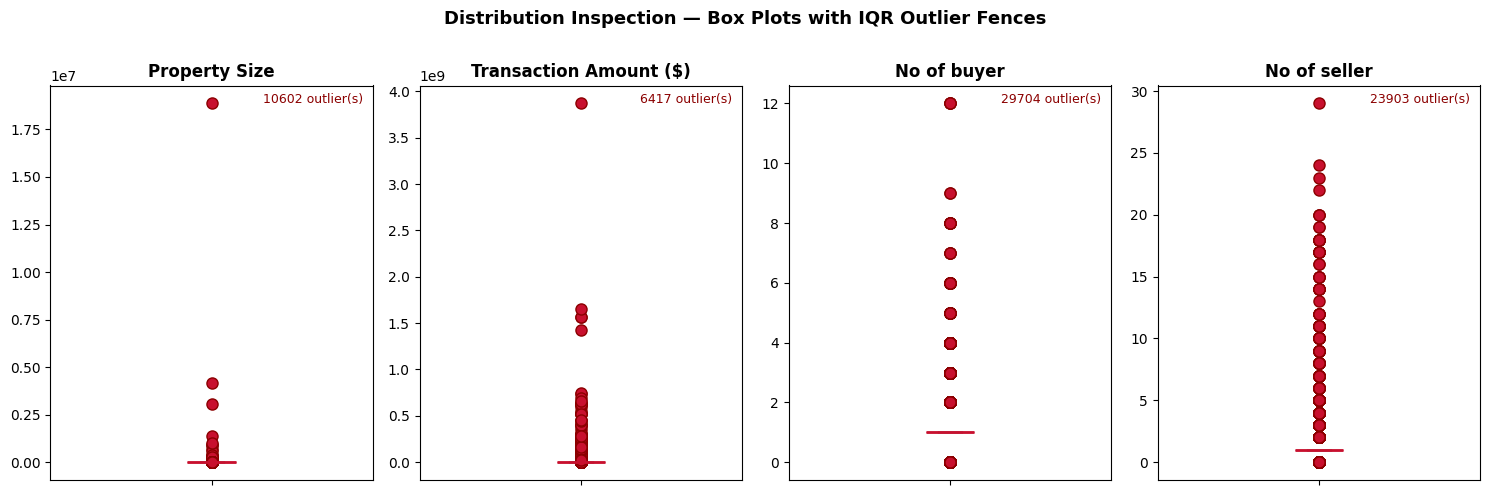

In [209]:
# 4a. Investigating outliers
print('=' * 60)
print('IQR-BASED OUTLIER SUMMARY AFTER CLEANING')
print('=' * 60)

for col_name in ['property_size_sqm', 'amount', 'no_of_buyer','no_of_seller']:
    series = df[col_name].dropna()
    if not series.empty:
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        high_outliers = series[series > upper_fence]
        low_outliers = series[series < lower_fence]

        total_rows_for_col = len(series)
        total_outliers = len(high_outliers) + len(low_outliers)
        outlier_percentage = (total_outliers / total_rows_for_col) * 100

        print(f'Column: {col_name}')
        print(f'  Lower Fence: {lower_fence:.2f}')
        print(f'  Upper Fence: {upper_fence:.2f}')
        print(f'  High Outliers: {len(high_outliers)} rows')
        print(f'  Low Outliers: {len(low_outliers)} rows')
        print(f'  Total Outliers: {total_outliers} rows ({outlier_percentage:.2f}%)')
        print()
    else:
        print(f'Column: {col_name} is empty after dropping NaN values.')
        print()

# 4b. Visualise distributions

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle('Distribution Inspection — Box Plots with IQR Outlier Fences',
             fontsize=13, fontweight='bold')

plot_cols = ['property_size_sqm', 'amount', 'no_of_buyer','no_of_seller']
titles = ['Property Size', 'Transaction Amount ($)', 'No of buyer','No of seller']

for ax, col, title in zip(axes, plot_cols, titles):
    data = df[col].dropna()
    # Box plot spans Q1-Q3; whiskers extend to IQR fences
    # Individual points beyond whiskers = flagged outliers
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#FFE4E4', color='#C8102E'),
               medianprops=dict(color='#C8102E', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#C8102E',
                               markeredgecolor='darkred', markersize=8))
    ax.set_title(title, fontweight='bold')
    ax.tick_params(labelbottom=False)
    # Annotate outlier count
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)).sum()
    ax.text(0.97, 0.98, f'{n_out} outlier(s)', transform=ax.transAxes,
            fontsize=9, color='darkred', va='top', ha='right')

plt.tight_layout()
plt.show()


In [210]:
# 4c. Investigating extreme values
print('=' * 60)
print('Property_size extreme values')
print('=' * 60)
display(df[(df['property_size_sqm'] > 0.25e7)])
print()
print('=' * 60)
print('Amount extreme values')
print('=' * 60)
display(df[(df['amount'] > 1e9)])




Property_size extreme values


,transaction_number,transaction_date,transaction_type,transaction_sub_type,registration_type,is_free_hold,usage,area,property_type,property_sub_type,amount,property_size_sqm,room,parking,nearest_metro,nearest_mall,nearest_landmark,no_of_buyer,no_of_seller,project
31320,11-10765-2023,2023-04-11 12:45:00,Sales,Sale,Ready,Free Hold,Residential,Al Layan1,Land,Land,6.307960e+08,3075848.63,NA,No Parking,NA,NA,Al Makhtoum International Airport,1,1,NA
31321,11-10766-2023,2023-04-11 12:48:00,Sales,Sale,Ready,Free Hold,Residential,Mugatrah,Land,Land,3.869204e+09,18866775.24,NA,No Parking,NA,NA,Al Makhtoum International Airport,1,1,NA
46614,11-6269-2023,2023-03-06 11:09:00,Sales,Sale,Ready,Free Hold,Residential,Dubai Creek Harbour,Land,Residential,1.570839e+09,4190636.66,NA,No Parking,Creek Metro Station,City Centre Mirdif,Dubai International Airport,1,1,NA



Amount extreme values


,transaction_number,transaction_date,transaction_type,transaction_sub_type,registration_type,is_free_hold,usage,area,property_type,property_sub_type,amount,property_size_sqm,room,parking,nearest_metro,nearest_mall,nearest_landmark,no_of_buyer,no_of_seller,project
31321,11-10766-2023,2023-04-11 12:48:00,Sales,Sale,Ready,Free Hold,Residential,Mugatrah,Land,Land,3.869204e+09,18866775.24,NA,No Parking,NA,NA,Al Makhtoum International Airport,1,1,NA
46614,11-6269-2023,2023-03-06 11:09:00,Sales,Sale,Ready,Free Hold,Residential,Dubai Creek Harbour,Land,Residential,1.570839e+09,4190636.66,NA,No Parking,Creek Metro Station,City Centre Mirdif,Dubai International Airport,1,1,NA
49543,11-8945-2023,2023-03-27 10:23:00,Sales,Sale,Ready,Free Hold,Residential,Dubai Creek Harbour,Land,Residential,1.570839e+09,678542.89,NA,No Parking,Creek Metro Station,City Centre Mirdif,Dubai International Airport,1,1,NA
53784,13-2832-2023,2023-02-23 10:58:00,Mortgage,Mortgage Registration,Ready,Free Hold,Residential,Palm Jumeirah,Unit,Hotel,1.430000e+09,312805.17,NA,Has Parking,Al Sufouh,Marina Mall,Burj Al Arab,0,0,"The Royal Atlantis,Resort And Residences"
60799,14-618-2023,2023-06-20 13:19:00,Mortgage,Modify Mortgage,Ready,Free Hold,Commercial,Al Kheeran,Land,Commercial,1.650000e+09,232542.91,NA,No Parking,Creek Metro Station,City Centre Mirdif,Dubai International Airport,0,0,NA


**Discussion:**
Based on the rows above, most of the outliers are 'Land' properties, therefore, they might be correct data since Land properties are larger compared to units, buildings. However, a hotel has a significantly high transaction amount, which could be wrong data and should be capped. Moreover, to analyse conveniently, the rest extreme data should also be capped to the highest value below them

In [211]:
# Cap the amount for 'Hotel' property type
upper_fence_amount = 5365000.0
hotel_indices = (df['property_sub_type'] == 'Hotel') & (df['amount'] > 1e9)
df.loc[hotel_indices, 'amount'] = upper_fence_amount

print(f"Capped amount for {hotel_indices.sum()} 'Hotel' properties to {upper_fence_amount}")

# Cap the extreme values of amount to the highest value below 1e9
upper_fence_amount = 1e9
df['amount'] = df['amount'].apply(lambda x: upper_fence_amount if x > upper_fence_amount else x)

print(f"Capped amount to {upper_fence_amount}")

# Cap the extreme values of property_size_sqm to the highest value below 0.25e7
upper_fence_sqm = 0.25e7
df['property_size_sqm'] = df['property_size_sqm'].apply(lambda x: upper_fence_sqm if x > upper_fence_sqm else x)

print(f"Capped property_size_sqm to {upper_fence_sqm}")

Capped amount for 1 'Hotel' properties to 5365000.0
Capped amount to 1000000000.0
Capped property_size_sqm to 2500000.0


## 6. Creating  derived variables

**Variable: price per sqm of each property**

In [212]:
# Create derived variable: price per sqm
df['price_per_sqm'] = (df['amount'] / df['property_size_sqm']).round(2)

# Display the DataFrame with the new column
display(df[['amount', 'property_size_sqm', 'price_per_sqm']].head())

,amount,property_size_sqm,price_per_sqm
0,2631000.0,105.75,24879.43
1,1466000.0,52.29,28035.95
2,3309000.0,161.32,20512.03
3,1170137.0,99.64,11743.65
4,590000.0,63.95,9225.96


#Load

In [213]:
# Drop the duplicated rows which might have been created after cleaning
df = df.drop_duplicates()

In [214]:
# Create a raw copy of the dataframe before any cleaning steps for 'Before vs After' comparisons
df_raw = pd.read_csv("dubai_property_sales.csv")


**Visualising before and after data clean**

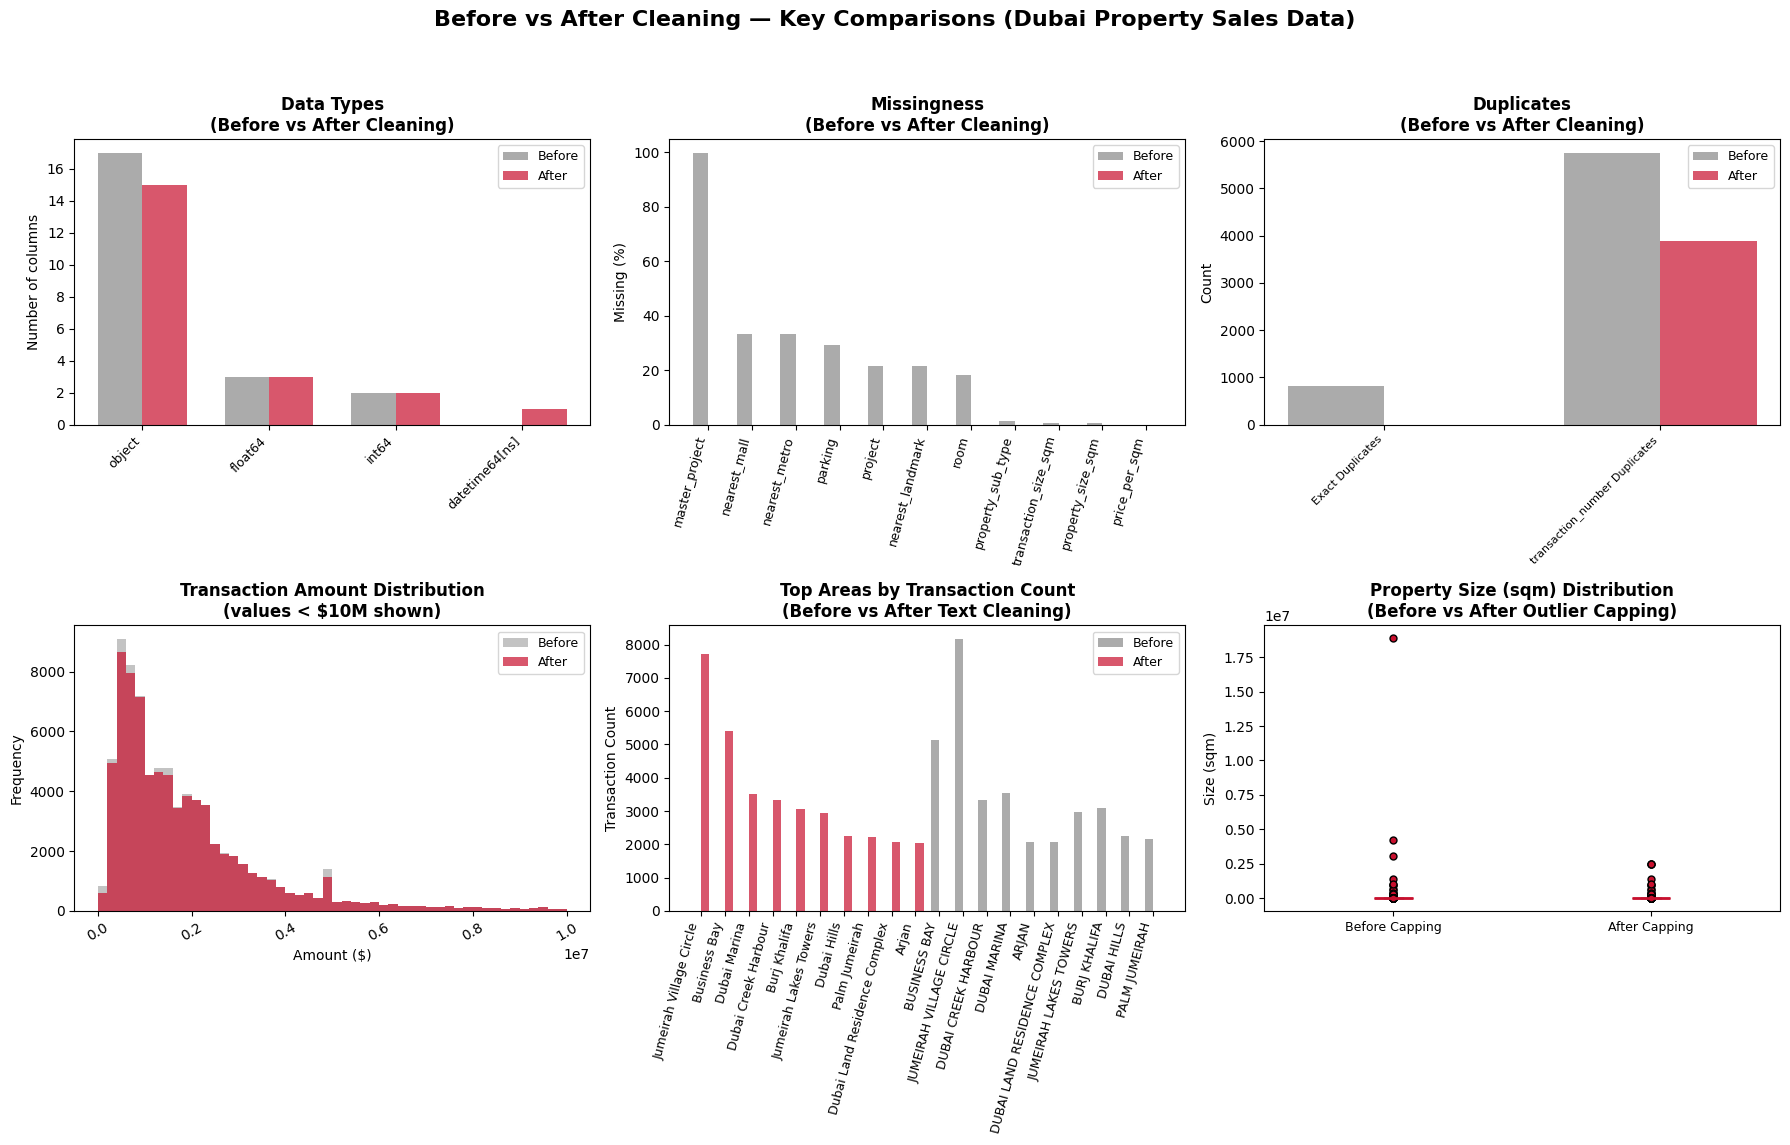

In [215]:
# --- Calculations for Panel 3 ---
# 1. Duplicate Records
raw_exact_duplicates = df_raw.duplicated().sum()
clean_exact_duplicates = df.duplicated().sum()

# 2. Key Integrity Duplicates (transaction_number)
raw_key_duplicates = df_raw['transaction_number'].duplicated().sum()
clean_key_duplicates = df['transaction_number'].duplicated().sum()

# --- Dashboard Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Adjusted figure size for better readability
fig.suptitle('Before vs After Cleaning — Key Comparisons (Dubai Property Sales Data)', fontsize=16, fontweight='bold', y=0.98)

width = 0.35 # Define width here for use across multiple panels

# --- Panel 1: Data type overview ---
ax = axes[0, 0]
raw_dtypes_vc = df_raw.dtypes.apply(str).value_counts()
clean_dtypes_vc = df.dtypes.apply(str).value_counts()

all_dtypes = pd.concat([raw_dtypes_vc, clean_dtypes_vc]).index.unique()

before_counts = [raw_dtypes_vc.get(dtype, 0) for dtype in all_dtypes]
after_counts = [clean_dtypes_vc.get(dtype, 0) for dtype in all_dtypes]

x_pos_dtypes = np.arange(len(all_dtypes))
ax.bar(x_pos_dtypes - width/2, before_counts, width, label='Before', color='#888', alpha=0.7)
ax.bar(x_pos_dtypes + width/2, after_counts, width, label='After', color='#C8102E', alpha=0.7)
ax.set_xticks(x_pos_dtypes)
ax.set_xticklabels(all_dtypes, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of columns', fontsize=10)
ax.set_title('Data Types\n(Before vs After Cleaning)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)


# --- Panel 2: Missing values before vs after cleaning ---
ax = axes[0, 1]
# Recalculate missingness for comparison
raw_missing_pct   = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
clean_missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# Only consider columns that had missing values in the raw data or still have them
all_missing_cols = pd.concat([raw_missing_pct[raw_missing_pct > 0], clean_missing_pct[clean_missing_pct > 0]]).index.unique()

before_plot = [raw_missing_pct.get(col, 0) for col in all_missing_cols]
after_plot = [clean_missing_pct.get(col, 0) for col in all_missing_cols]

x_pos_missing = np.arange(len(all_missing_cols))

ax.bar(x_pos_missing - width/2, before_plot, width, label='Before', color='#888', alpha=0.7)
ax.bar(x_pos_missing + width/2, after_plot, width, label='After', color='#C8102E', alpha=0.7)
ax.set_xticks(x_pos_missing)
ax.set_xticklabels(all_missing_cols, rotation=75, ha='right', fontsize=9)
ax.set_ylabel('Missing (%)', fontsize=10)
ax.set_title('Missingness\n(Before vs After Cleaning)', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

# --- Panel 3: Duplicate Records ---
ax = axes[0, 2]
metrics = [
    'Exact Duplicates',
    'transaction_number Duplicates'
]
before_values = [raw_exact_duplicates, raw_key_duplicates]
after_values = [clean_exact_duplicates, clean_key_duplicates]

x = np.arange(len(metrics))

rects1 = ax.bar(x - width/2, before_values, width, label='Before', color='#888', alpha=0.7)
rects2 = ax.bar(x + width/2, after_values, width, label='After', color='#C8102E', alpha=0.7)

ax.set_ylabel('Count', fontsize=10)
ax.set_title('Duplicates\n(Before vs After Cleaning)', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=8)

# --- Panel 4: Amount distribution (showing values within a reasonable range) ---
ax = axes[1, 0]
raw_amount_dist  = df_raw['amount']
clean_amount_dist = df['amount']

# Define a reasonable cap for visualization to show the bulk of data
visual_cap = 1.0e7
ax.hist(raw_amount_dist[raw_amount_dist < visual_cap], bins=50, alpha=0.5, color='#888', label='Before')
ax.hist(clean_amount_dist[clean_amount_dist < visual_cap], bins=50, alpha=0.7, color='#C8102E', label='After')
ax.set_title('Transaction Amount Distribution\n(values < $10M shown)', fontweight='bold', fontsize=12)
ax.set_xlabel('Amount ($)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

# --- Panel 5: Area categorical consistency ---
ax = axes[1, 1]
raw_area_vc = df_raw['area'].value_counts().nlargest(10) # Top 10 for before
clean_area_vc = df['area'].value_counts().nlargest(10) # Top 10 for after (already cleaned)

# Combine for plotting
combined_areas = pd.concat([raw_area_vc, clean_area_vc], axis=1, keys=['Before', 'After']).fillna(0)
combined_areas = combined_areas.sort_values(by='After', ascending=False) # Sort by after counts

x_pos = np.arange(len(combined_areas))

ax.bar(x_pos - width/2, combined_areas['Before'], width, label='Before', color='#888', alpha=0.7)
ax.bar(x_pos + width/2, combined_areas['After'], width, label='After', color='#C8102E', alpha=0.7)
ax.set_title('Top Areas by Transaction Count\n(Before vs After Text Cleaning)', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(combined_areas.index, rotation=75, ha='right', fontsize=9)
ax.set_ylabel('Transaction Count', fontsize=10)
ax.legend(fontsize=9)


# --- Panel 6: Property Size (sqm) box plots ---
ax = axes[1, 2]
raw_size_data   = df_raw['property_size_sqm'].dropna()
clean_size_data = df['property_size_sqm'].dropna()

bp = ax.boxplot([raw_size_data, clean_size_data],
                patch_artist=True, labels=['Before Capping', 'After Capping'],
                boxprops=dict(facecolor='#FFE4E4', color='#C8102E'),
                medianprops=dict(color='#C8102E', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#C8102E', markersize=5))
ax.set_title('Property Size (sqm) Distribution\n(Before vs After Outlier Capping)', fontweight='bold', fontsize=12)
ax.set_ylabel('Size (sqm)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)



plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [216]:
# Export the cleaned dataset to CSV
output_path = 'dubai_property_sales_cleaned.csv'
df.to_csv(output_path, index=False)
print('='*60)
print('Final dataset summary:')
print('='*60)
print(f'  Rows            : {len(df):,}')
print(f'  Columns         : {df.shape[1]}')
print(f'  Variable names and types:')
print(df.dtypes.to_string())
print(f'  Missing values  : {df['property_size_sqm'].isnull().sum()} value in ''property_size_sqm''')
print(f'  Duplicate rows  : {df.duplicated().sum()}')
print(f'  transaction_number unique: {df["transaction_number"].is_unique}')
print('='*60)
print(' Data is cleaned and loaded as ''dubai_property_sales_cleaned.csv'' for future analysis')
print('='*60)

Final dataset summary:
  Rows            : 79,729
  Columns         : 21
  Variable names and types:
transaction_number              object
transaction_date        datetime64[ns]
transaction_type                object
transaction_sub_type            object
registration_type               object
is_free_hold                    object
usage                           object
area                            object
property_type                   object
property_sub_type               object
amount                         float64
property_size_sqm              float64
room                            object
parking                         object
nearest_metro                   object
nearest_mall                    object
nearest_landmark                object
no_of_buyer                      int64
no_of_seller                     int64
project                         object
price_per_sqm                  float64
  Missing values  : 1 value in property_size_sqm
  Duplicate rows  : 0
  transac

#**PART 2: Exploration**

In [217]:
# Read the cleaned dataset
df_cleaned = pd.read_csv('dubai_property_sales_cleaned.csv', keep_default_na=False)
# Filter the dataset with unique transaction_number
df_exploration = df_cleaned.drop_duplicates(subset='transaction_number')

## Question 1: Property Subtype and Sale Amount

Unique values in 'property_sub_type':
36


Unique transaction numbers by 'property_sub_type':
Flat                           51290      (67.62%) 
Villa                          7435       ( 9.80%) 
Residential                    6339       ( 8.36%) 
Commercial                     2500       ( 3.30%) 
Hotel Apartment                1906       ( 2.51%) 
Office                         1767       ( 2.33%) 
Land                           1550       ( 2.04%) 
Hotel Rooms                    1051       ( 1.39%) 
Shop                           629        ( 0.83%) 
Government Housing             548        ( 0.72%) 
Residential Flats              225        ( 0.30%) 
Industrial                     152        ( 0.20%) 
General Use                    130        ( 0.17%) 
Airport                        121        ( 0.16%) 
Hospital                       75         ( 0.10%) 
Agricultural                   26         ( 0.03%) 
Unit                           23         ( 0.03%) 
Stacked Townhouses    

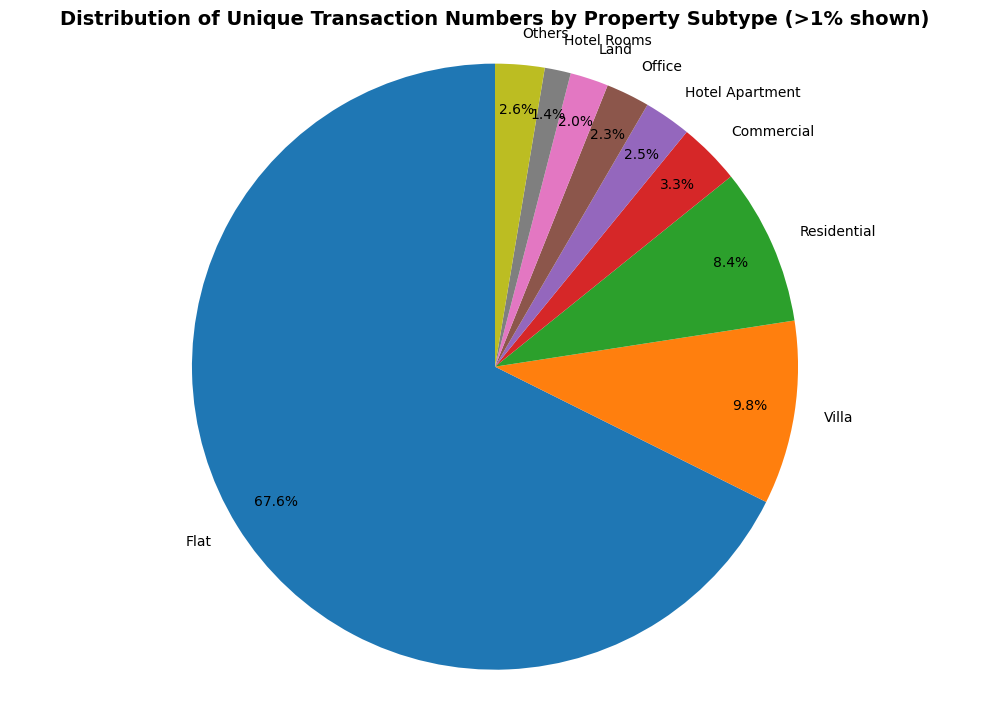

In [218]:
#==========================Transaction Count Distribution=====================================
# Count the unique values of Subtype
print("Unique values in 'property_sub_type':")
print(df_exploration['property_sub_type'].nunique())
print()

# Display value counts for 'property_sub_type' with percentages based on unique transaction numbers
print("\nUnique transaction numbers by 'property_sub_type':")
unique_transactions_per_subtype = df_exploration.groupby('property_sub_type')['transaction_number'].nunique().sort_values(ascending=False)
total_unique_transactions = df_exploration['transaction_number'].nunique()
percentages_unique_transactions = (unique_transactions_per_subtype / total_unique_transactions * 100).round(2)

for subtype, count in unique_transactions_per_subtype.items():
    print(f"{subtype:<30} {count:<10} ({percentages_unique_transactions[subtype]:>5.2f}%) ")

# Pie chart showing the distribution of unique transaction numbers by property subtype
unique_transactions_per_subtype = df_exploration.groupby('property_sub_type')['transaction_number'].nunique().sort_values(ascending=False)
total_unique_transactions = df_exploration['transaction_number'].nunique()
percentages_unique_transactions = (unique_transactions_per_subtype / total_unique_transactions * 100).round(2)

# Filter for subtypes > 1% and group the rest into 'Others'
major_subtypes = percentages_unique_transactions[percentages_unique_transactions > 1]
other_percentage = percentages_unique_transactions[percentages_unique_transactions <= 1].sum().round(2)

if other_percentage > 0:
    plot_percentages = pd.concat([major_subtypes, pd.Series([other_percentage], index=['Others'])])
else:
    plot_percentages = major_subtypes

# Prepare data for plotting
labels = plot_percentages.index
sizes = plot_percentages.values

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribution of Unique Transaction Numbers by Property Subtype (>1% shown)', fontsize=14, fontweight='bold')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [219]:
# Summary table for property subtype
subtype_summary = (
    df_exploration.groupby("property_sub_type")["amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Keep only subtypes with enough records
subtype_summary_filtered = subtype_summary[subtype_summary["count"] >= 30]

# Sort by median sale amount
subtype_summary_filtered = subtype_summary_filtered.sort_values(
    by="median", ascending=False
)

subtype_summary_filtered.head(10)

,property_sub_type,count,mean,median,min,max,q1,q3
24,Residential Flats,225,2.385730e+07,1.350000e+07,1080180.00,7.493525e+08,7700000.00,23209888.0
16,Industrial,152,2.502203e+07,1.012447e+07,1000000.00,6.930000e+08,5775000.00,23237530.5
9,General Use,130,1.227293e+07,9.050000e+06,2226074.00,9.250000e+07,6926000.00,12476120.0
4,Commercial,2500,1.694470e+07,5.000000e+06,57.00,1.000000e+09,2804429.50,12945600.0
1,Airport,121,1.267000e+07,4.117888e+06,795109.00,6.595382e+08,3168888.00,8000000.0
21,Residential,6339,5.470291e+06,2.633760e+06,1141.58,1.000000e+09,1959000.00,4828500.0
33,Villa,7435,2.824700e+06,2.206888e+06,50000.00,1.830000e+08,1780888.00,3049888.0
12,Hospital,75,2.910760e+06,2.072166e+06,262854.68,1.577747e+07,438733.58,5010280.0
18,Land,1550,7.974556e+06,1.594668e+06,265000.00,1.000000e+09,1000000.00,5765845.2
14,Hotel Apartment,1906,2.394765e+06,1.327454e+06,237350.00,7.650000e+07,620542.50,3050000.0


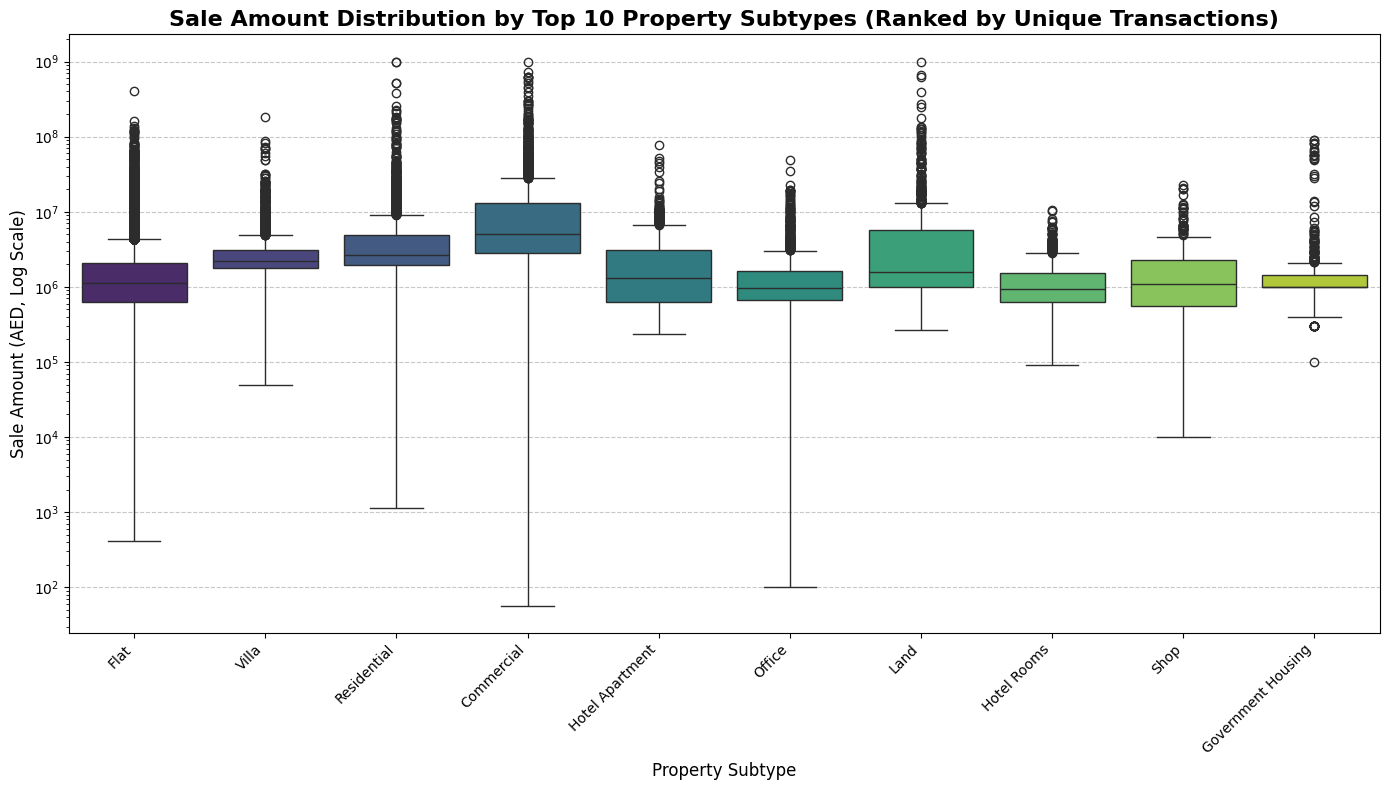

In [220]:
#==========================Transaction Amount Distribution=====================================
# Get the top 10 property subtypes by unique transaction counts
top_10_subtypes = unique_transactions_per_subtype.nlargest(10).index.tolist()

# Filter the DataFrame to include only these top 10 subtypes
df_top_10_subtypes = df_exploration[df_exploration['property_sub_type'].isin(top_10_subtypes)].copy()



# Ensure the subtypes are ordered correctly for the plot
df_top_10_subtypes['property_sub_type'] = pd.Categorical(df_top_10_subtypes['property_sub_type'], categories=top_10_subtypes, ordered=True)

plt.figure(figsize=(14, 8))
sns.boxplot(x='property_sub_type', y='amount', data=df_top_10_subtypes, palette='viridis')
plt.title('Sale Amount Distribution by Top 10 Property Subtypes (Ranked by Unique Transactions)', fontsize=16, fontweight='bold')
plt.xlabel('Property Subtype', fontsize=12)
plt.ylabel('Sale Amount (AED, Log Scale)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yscale('log') # Use a log scale for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

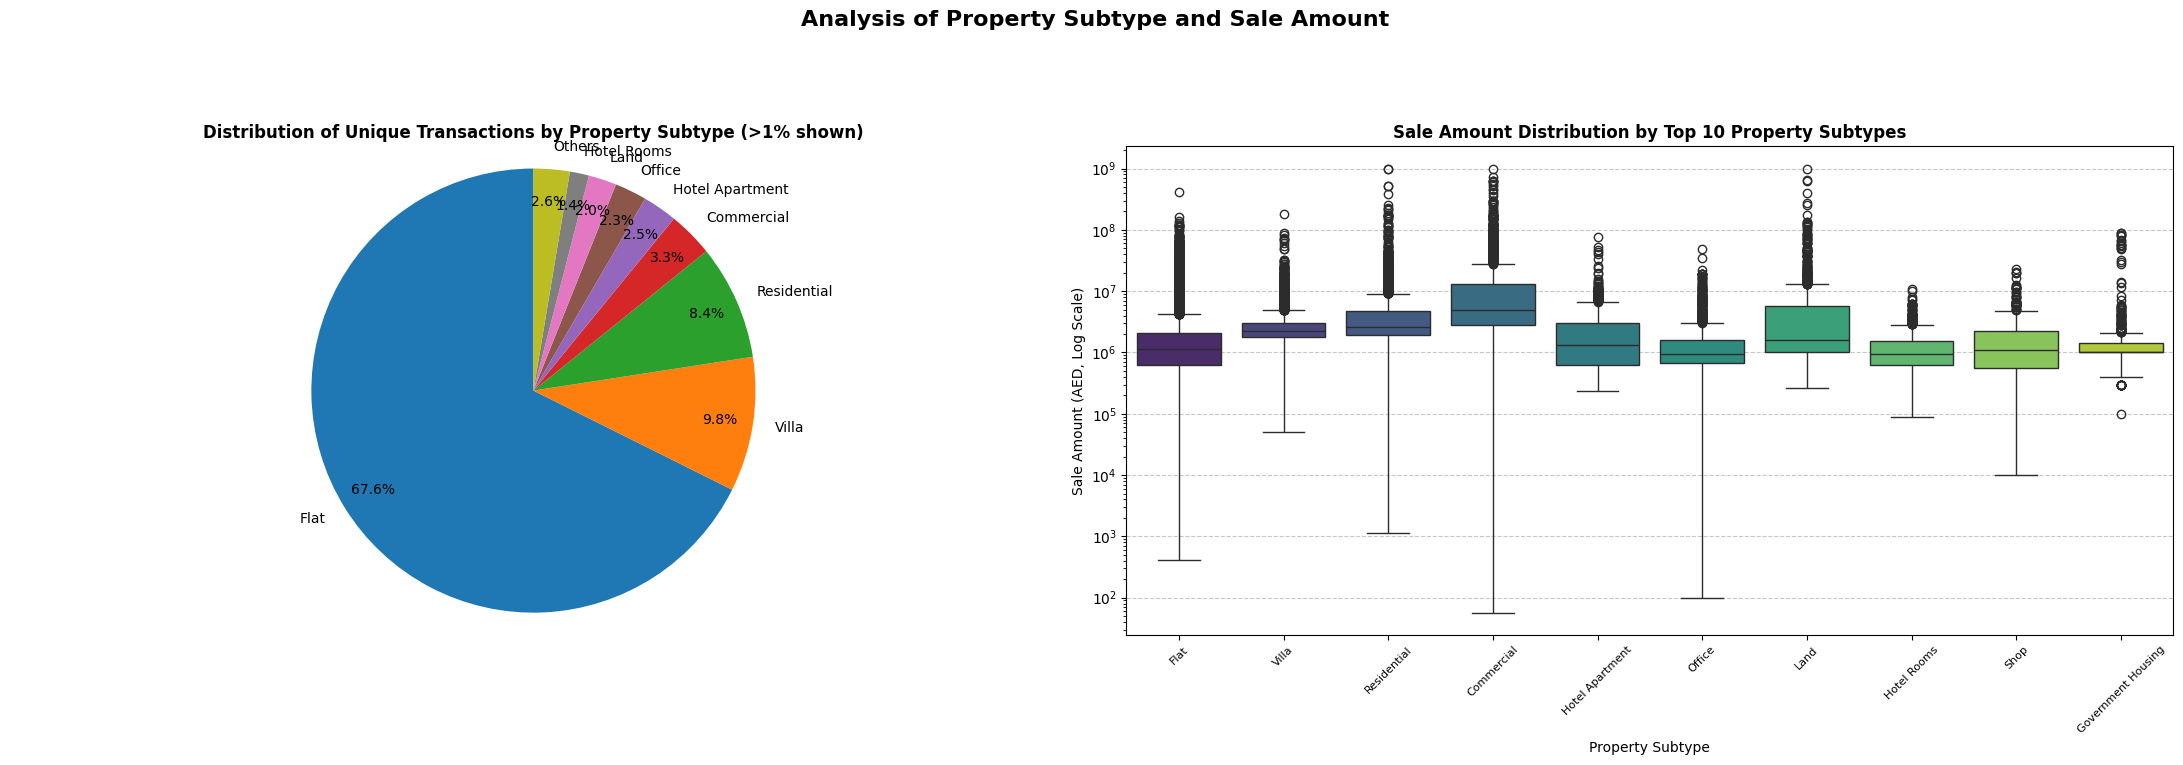

In [221]:
#======================SUMMARY DASHBOARD FOR QUESTION 1========================================================
# --- Prepare data for Pie Chart (from cell 7534d8dd) ---
unique_transactions_per_subtype = df_exploration.groupby('property_sub_type')['transaction_number'].nunique().sort_values(ascending=False)
total_unique_transactions = df_exploration['transaction_number'].nunique()
percentages_unique_transactions = (unique_transactions_per_subtype / total_unique_transactions * 100).round(2)

# Filter for subtypes > 1% and group the rest into 'Others'
major_subtypes = percentages_unique_transactions[percentages_unique_transactions > 1]
other_percentage = percentages_unique_transactions[percentages_unique_transactions <= 1].sum().round(2)

if other_percentage > 0:
    plot_percentages = pd.concat([major_subtypes, pd.Series([other_percentage], index=['Others'])])
else:
    plot_percentages = major_subtypes

labels = plot_percentages.index
sizes = plot_percentages.values

# --- Prepare data for Box Plot (from cell YeFATiD94ojN) ---
top_10_subtypes = unique_transactions_per_subtype.nlargest(10).index.tolist()
df_top_10_subtypes = df_exploration[df_exploration['property_sub_type'].isin(top_10_subtypes)].copy()
df_top_10_subtypes['property_sub_type'] = pd.Categorical(df_top_10_subtypes['property_sub_type'], categories=top_10_subtypes, ordered=True)

# --- Create the Dashboard ---
fig, axes = plt.subplots(1, 2, figsize=(22, 8)) # 1 row, 2 columns for the plots
fig.suptitle('Analysis of Property Subtype and Sale Amount', fontsize=16, fontweight='bold')

# Plot 1: Pie Chart - Distribution of Unique Transaction Numbers by Property Subtype
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[0].set_title('Distribution of Unique Transactions by Property Subtype (>1% shown)', fontsize=12, fontweight='bold')
axes[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Plot 2: Box Plot - Sale Amount Distribution by Top 10 Property Subtypes
sns.boxplot(x='property_sub_type', y='amount', data=df_top_10_subtypes, palette='viridis', ax=axes[1])
axes[1].set_title('Sale Amount Distribution by Top 10 Property Subtypes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Property Subtype', fontsize=10)
axes[1].set_ylabel('Sale Amount (AED, Log Scale)', fontsize=10)
axes[1].set_yscale('log') # Use a log scale for the y-axis
axes[1].tick_params(axis='x', rotation=45, labelsize=8) # Rotate x-axis labels
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()

## Question 2: Area and Sale Price Variation:

In [222]:
#==========================Statistic Summary=====================================
area_summary = (
    df_exploration.groupby("area")["amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Keep areas with enough transactions
area_summary_filtered = area_summary[area_summary["count"] >= 100]

# Highest median price areas
top_areas = area_summary_filtered.sort_values(
    by="median", ascending=False
).head(10)

# Lowest median price areas
bottom_areas = area_summary_filtered.sort_values(
    by="median", ascending=True
).head(10)

top_areas

,area,count,mean,median,min,max,q1,q3
27,Al Hebiah Fourth,399,8.769118e+06,8800000.00,978500.0,45326000.0,3.600000e+06,9882650.0
244,Wadi Al Safa 3,308,1.286231e+07,8040000.00,300000.0,170000000.0,5.904717e+06,12416350.0
151,Jumeirah Islands,127,8.790947e+06,7850000.00,214644.0,24000000.0,5.000000e+06,10775000.0
250,Zaabeel First,115,1.292730e+07,7429000.00,4216000.0,516075778.0,4.800500e+06,9776000.0
95,Bluewaters,117,8.583760e+06,7000000.00,250000.0,80000000.0,5.100000e+06,9180000.0
176,Me'Aisem First,212,7.195946e+06,5301715.00,123865.4,105149040.0,4.092500e+06,7824325.0
194,Nad Al Shiba First,194,5.358763e+06,4510000.00,750000.0,17000000.0,3.842000e+06,5062000.0
154,Jumeirah Park,306,4.475187e+06,4400000.00,1000000.0,16000000.0,3.400000e+06,5093750.0
228,The Villa,147,4.417634e+06,4250000.00,877469.0,9200000.0,3.125000e+06,5500000.0
173,Marsa Dubai,1472,5.977938e+06,3994625.24,985000.0,623067617.3,3.247920e+06,5931500.0


Number of unique areas: 252
Value counts and percentages for 'area':
Jumeirah Village Circle        7220       ( 9.52%) 
Business Bay                   5271       ( 6.95%) 
Dubai Marina                   3396       ( 4.48%) 
Dubai Creek Harbour            3330       ( 4.39%) 
Burj Khalifa                   3015       ( 3.98%) 
Jumeirah Lakes Towers          2899       ( 3.82%) 
Dubai Hills                    2246       ( 2.96%) 
Dubai Land Residence Complex   2063       ( 2.72%) 
Al Hebiah Fifth                2015       ( 2.66%) 
Arjan                          1935       ( 2.55%) 
Palm Jumeirah                  1925       ( 2.54%) 
Al Furjan                      1659       ( 2.19%) 
Sobha Heartland                1646       ( 2.17%) 
Marsa Dubai                    1472       ( 1.94%) 
Damac Hills                    1274       ( 1.68%) 
Town Square                    1274       ( 1.68%) 
International City Ph 1        1260       ( 1.66%) 
Silicon Oasis                  1129       ( 1.4

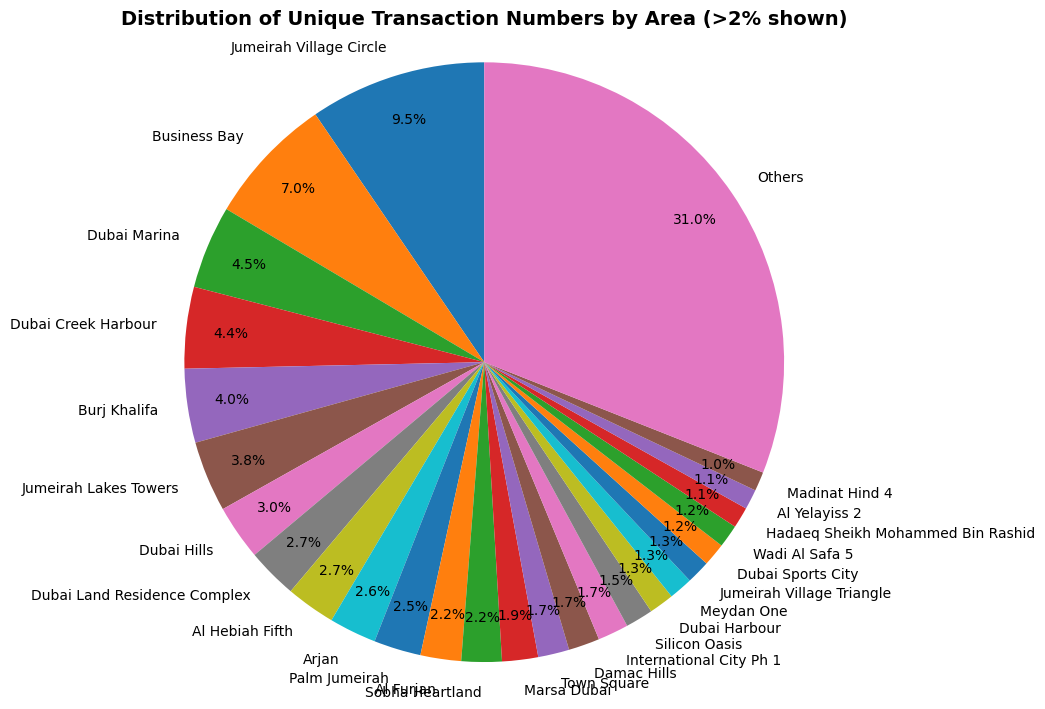

In [223]:
#==========================Transaction Count Distribution=====================================
print(f"Number of unique areas: {df_exploration['area'].nunique()}")
print("Value counts and percentages for 'area':")
area_counts = df_exploration['area'].value_counts()
area_percentages = (area_counts / len(df_exploration) * 100).round(2)

for area, count in area_counts.items():
    print(f"{area:<30} {count:<10} ({area_percentages[area]:>5.2f}%) ")

# Calculate unique transaction numbers per area
unique_transactions_per_area = df_exploration.groupby('area')['transaction_number'].nunique().sort_values(ascending=False)
total_unique_transactions_area = df_exploration['transaction_number'].nunique()
percentages_unique_transactions_area = (unique_transactions_per_area / total_unique_transactions_area * 100).round(2)

# Filter for areas > 0.25% and group the rest into 'Others'
major_areas = percentages_unique_transactions_area[percentages_unique_transactions_area > 1]
other_percentage_area = percentages_unique_transactions_area[percentages_unique_transactions_area <= 1].sum().round(2)

if other_percentage_area > 0:
    plot_percentages_area = pd.concat([major_areas, pd.Series([other_percentage_area], index=['Others'])])
else:
    plot_percentages_area = major_areas

# Prepare data for plotting
labels_area = plot_percentages_area.index
sizes_area = plot_percentages_area.values

plt.figure(figsize=(10, 8))
plt.pie(sizes_area, labels=labels_area, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribution of Unique Transaction Numbers by Area (>2% shown)', fontsize=14, fontweight='bold')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [224]:
#============================Price_per_sqm Amount Distribution=====================================
# Filter the area with more than 100 transaction counts
area_filtered = area_summary[area_summary["count"] >= 100]

# Get the list of valid area names
valid_areas = area_filtered['area'].tolist()

# Filter df_exploration to include only these valid areas
df_relevant_areas = df_exploration[df_exploration['area'].isin(valid_areas)]

# Calculate the mean price_per_sqm for each relevant area
area_price_per_sqm = df_relevant_areas.groupby('area')['price_per_sqm'].mean().sort_values(ascending=False)

# --- Top 20 Areas ---
# Select the top 20 areas for visualization
top_20_areas_names = area_price_per_sqm.head(20).index.tolist()

# Filter the relevant dataframe to include only these selected areas
df_top_20_areas = df_relevant_areas[df_relevant_areas['area'].isin(top_20_areas_names)].copy()

# Ensure the areas are ordered correctly for the plot
df_top_20_areas['area'] = pd.Categorical(df_top_20_areas['area'], categories=top_20_areas_names, ordered=True)

# Create the box plot for top 20 areas
plt.figure(figsize=(18, 10)) # Increased figure size for better readability
sns.boxplot(x='area', y='price_per_sqm', data=df_top_20_areas, palette='viridis', fliersize=3) # Reduced fliersize for less clutter

plt.title('Distribution of Price Per Square Meter Across Top 20 Areas in Dubai (Box Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Area', fontsize=12)
plt.ylabel('Price Per SQM (AED)', fontsize=12)
plt.xticks(rotation=75, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Bottom 20 Areas ---
# Select the bottom 20 areas for visualization
bottom_20_areas_names = area_price_per_sqm.tail(20).index.tolist()

# Filter the relevant dataframe to include only these selected areas
df_bottom_20_areas = df_relevant_areas[df_relevant_areas['area'].isin(bottom_20_areas_names)].copy()

# Ensure the areas are ordered correctly for the plot
df_bottom_20_areas['area'] = pd.Categorical(df_bottom_20_areas['area'], categories=bottom_20_areas_names, ordered=True)

# Create the box plot for bottom 20 areas
plt.figure(figsize=(18, 10)) # Increased figure size for better readability
sns.boxplot(x='area', y='price_per_sqm', data=df_bottom_20_areas, palette='plasma', fliersize=3) # Reduced fliersize for less clutter

plt.title('Distribution of Price Per Square Meter Across Bottom 20 Areas in Dubai (Box Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Area', fontsize=12)
plt.ylabel('Price Per SQM (AED)', fontsize=12)
plt.xticks(rotation=75, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
#===============SUMMARY DASHBOARD FOR QUESTION 2=========================
# --- Prepare data for Pie Chart (from cell qD_reyYgd255) ---
unique_transactions_per_area = df_exploration.groupby('area')['transaction_number'].nunique().sort_values(ascending=False)
total_unique_transactions_area = df_exploration['transaction_number'].nunique()
percentages_unique_transactions_area = (unique_transactions_per_area / total_unique_transactions_area * 100).round(2)

# Filter for areas > 2% and group the rest into 'Others' as per prompt context
major_areas = percentages_unique_transactions_area[percentages_unique_transactions_area > 2]
other_percentage_area = percentages_unique_transactions_area[percentages_unique_transactions_area <= 2].sum().round(2)

if other_percentage_area > 0:
    plot_percentages_area = pd.concat([major_areas, pd.Series([other_percentage_area], index=['Others'])])
else:
    plot_percentages_area = major_areas

labels_area = plot_percentages_area.index
sizes_area = plot_percentages_area.values

# --- Prepare data for Box Plots (from cell 7cBoS8SM5dp6) ---
# Use area_summary_filtered from cell VLavp2RB_XHb
valid_areas = area_summary_filtered['area'].tolist()
df_relevant_areas = df_exploration[df_exploration['area'].isin(valid_areas)]
area_price_per_sqm = df_relevant_areas.groupby('area')['price_per_sqm'].mean().sort_values(ascending=False)

# Top 20 Areas
top_20_areas_names = area_price_per_sqm.head(20).index.tolist()
df_top_20_areas = df_relevant_areas[df_relevant_areas['area'].isin(top_20_areas_names)].copy()
df_top_20_areas['area'] = pd.Categorical(df_top_20_areas['area'], categories=top_20_areas_names, ordered=True)

# Bottom 20 Areas
bottom_20_areas_names = area_price_per_sqm.tail(20).index.tolist()
df_bottom_20_areas = df_relevant_areas[df_relevant_areas['area'].isin(bottom_20_areas_names)].copy()
df_bottom_20_areas['area'] = pd.Categorical(df_bottom_20_areas['area'], categories=bottom_20_areas_names, ordered=True)

# --- Create the Dashboard ---
fig, axes = plt.subplots(1, 3, figsize=(25, 8)) # 1 row, 3 columns for pie chart and two box plots
# Removed: fig.suptitle('Analysis of Area and Sale Price Variation', fontsize=16, fontweight='bold')

# Plot 1: Pie Chart - Distribution of Unique Transaction Numbers by Area
axes[0].pie(sizes_area, labels=labels_area, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[0].set_title('Distribution of Unique Transaction Numbers by Area (>2% shown)', fontsize=12, fontweight='bold')
axes[0].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Plot 2: Box Plot - Top 20 Areas by Price Per Square Meter
sns.boxplot(x='area', y='price_per_sqm', data=df_top_20_areas, palette='viridis', fliersize=3, ax=axes[1])
axes[1].set_title('Distribution of Price Per Square Meter Across Top 20 Areas', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Area', fontsize=12)
axes[1].set_ylabel('Price Per SQM (AED)', fontsize=12)
axes[1].tick_params(axis='x', rotation=75, labelsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Box Plot - Bottom 20 Areas by Price Per Square Meter
sns.boxplot(x='area', y='price_per_sqm', data=df_bottom_20_areas, palette='plasma', fliersize=3, ax=axes[2])
axes[2].set_title('Distribution of Price Per Square Meter Across Bottom 20 Areas', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Area', fontsize=12)
axes[2].set_ylabel('Price Per SQM (AED)', fontsize=12)
axes[2].tick_params(axis='x', rotation=75, labelsize=8)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
plt.show()